# Vacation Package Project

## Objective
- A travel agency has asked you and your team to create a machine learning model to help them predict whether or not potential customers will purchase a new vacation package they are offering.  As part of this process, the agency would also like to understand the potential customers better to more efficiently market their new package.  Your current task is to prepare and optimize the data set that will be used to build the prediction model. At this point, various models will be built and evaluated (logistic regression, decision tree, random forest, etc.)  In order to properly prepare the data set you will need to complete appropriate data overview, data preprocessing, EDA, and feature engineering tasks. 

# Data Information
Data Dictionary:

CustomerID: Unique customer ID <br>
ProdTaken: Whether the customer has purchased a package or not (0: No, 1: Yes) <br>
Age: Age of customer <br>
TypeofContact: How customer was contacted (Company Invited or Self Inquiry) <br>
CityTier: City tier depends on the development of a city, population, facilities, and living standards. The categories are ordered i.e. Tier 1 > Tier 2 > Tier 3 <br>
DurationOfPitch: Duration of the pitch by a salesperson to the customer<br>
Occupation: Occupation of customer<br>
Gender: Gender of customer<br>
NumberOfPersonVisiting: Total number of people planning to take the trip with the customer<br>
NumberOfFollowups: Total number of follow-ups has been done by the salesperson after the sales pitch<br>
ProductPitched: Product pitched by the salesperson<br>
PreferredPropertyStar: Preferred hotel property rating by customer<br>
MaritalStatus: Marital status of customer<br>
NumberOfTrips: Average number of trips in a year by customer<br>
Passport: The customer has a passport or not (0: No, 1: Yes)<br>
PitchSatisfactionScore: Sales pitch satisfaction score<br>
OwnCar: Whether the customers own a car or not (0: No, 1: Yes)<br>
NumberOfChildrenVisiting: Total number of children with age less than 5 planning to take the trip with the customer<br>
Designation: Designation of the customer in the current organization<br>
MonthlyIncome: Gross monthly income of the customer<br>

# Import Libraries

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy import stats

# Load Dataset

In [2]:
df = pd.read_csv("C:/AI Class/vacation_package.csv")

# Data Overview

In [3]:
df.shape

(4888, 20)

In [4]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [5]:
df.sample(10)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
1370,201370,0,47.0,Company Invited,1,20.0,Large Business,Male,3,3.0,Deluxe,4.0,Married,1.0,0,3,0,2.0,Manager,20467.0
3559,203559,0,35.0,Self Enquiry,1,14.0,Small Business,Male,3,4.0,Basic,3.0,Unmarried,3.0,0,1,0,2.0,Executive,21650.0
4787,204787,0,37.0,Self Enquiry,1,13.0,Salaried,Male,3,6.0,Basic,3.0,Married,3.0,0,1,1,1.0,Executive,21419.0
2074,202074,0,42.0,Self Enquiry,1,NaN,Salaried,Male,3,3.0,Deluxe,4.0,Married,2.0,0,3,1,0.0,Manager,NaN
3603,203603,0,40.0,Company Invited,1,11.0,Small Business,Fe Male,3,4.0,Deluxe,3.0,Unmarried,2.0,0,3,1,1.0,Manager,23720.0
1842,201842,0,35.0,Self Enquiry,1,15.0,Salaried,Male,3,4.0,Deluxe,4.0,Unmarried,1.0,0,1,0,1.0,Manager,21540.0
529,200529,0,38.0,Self Enquiry,1,6.0,Salaried,Female,2,2.0,Deluxe,3.0,Unmarried,1.0,0,2,1,1.0,Manager,22625.0
212,200212,0,27.0,Company Invited,3,26.0,Salaried,Fe Male,2,3.0,Deluxe,3.0,Unmarried,2.0,0,2,1,1.0,Manager,24981.0
462,200462,0,34.0,Self Enquiry,3,27.0,Salaried,Male,3,2.0,Deluxe,3.0,Single,2.0,0,3,1,0.0,Manager,20337.0
1529,201529,0,37.0,Self Enquiry,1,6.0,Salaried,Male,2,4.0,Deluxe,3.0,Married,2.0,0,5,0,0.0,Manager,20993.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [9]:
df.nunique()

CustomerID                  4888
ProdTaken                      2
Age                           44
TypeofContact                  2
CityTier                       3
DurationOfPitch               34
Occupation                     4
Gender                         3
NumberOfPersonVisiting         5
NumberOfFollowups              6
ProductPitched                 5
PreferredPropertyStar          3
MaritalStatus                  4
NumberOfTrips                 12
Passport                       2
PitchSatisfactionScore         5
OwnCar                         2
NumberOfChildrenVisiting       4
Designation                    5
MonthlyIncome               2475
dtype: int64

In [10]:
df['ProdTaken'].value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

Observations throughout the data overview:
- Age is float which should be int
- NumberOfFollowups should be int
- NumberOfTrips should be int
- NumberOfChildrenVisiting should be an int
- There seem to be null values in DurationOfPitch, NumberOfFollowups, PreferredPropertyStar, Age, TypeOfContact, NumberOfTrips, Number of Children Visiting, and MonthlyIncome
- Customer ID column can be removed too unique
-There were 3968 people who didn't purchase and 920 that did.

# Data Preprocessing

In [11]:
df = df.drop(['CustomerID'], axis=1)

## Duplicate Data

In [12]:
df.duplicated().sum()

np.int64(141)

No duplicated data

## Missing Values

In [13]:
(df == "?").sum().sum()

np.int64(0)

In [14]:
df.isnull().sum()

ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

Missing values are located in Age, TypeofContact, DurationOfPitch, NumberOfFollowups, PreferredPropertyStar, NumberOfTrips, NumberOfChildrenVisiting, and MonthlyIncome

### Age

In [15]:
df.Age.describe()

count    4662.000000
mean       37.622265
std         9.316387
min        18.000000
25%        31.000000
50%        36.000000
75%        44.000000
max        61.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

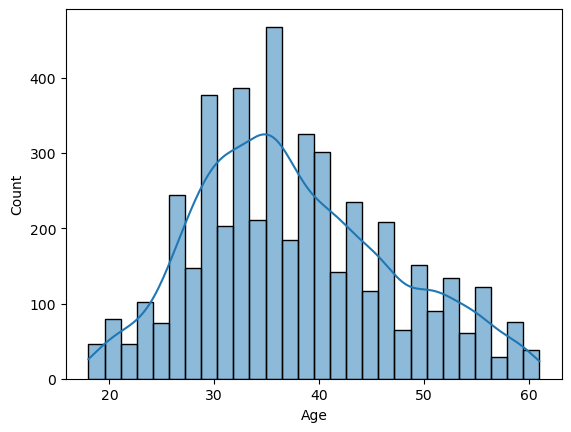

In [16]:
sns.histplot(df['Age'], kde = True)

In [17]:
df.loc[df['Age'].isnull(), 'Age'] = df['Age'].median()

In [18]:
df['Age'].isnull().sum()

np.int64(0)

I filled in the missing values with the median since the data was slightly skewed right

### TypeofContact

In [19]:
df.TypeofContact.describe()

count             4863
unique               2
top       Self Enquiry
freq              3444
Name: TypeofContact, dtype: object

<Axes: xlabel='TypeofContact', ylabel='Count'>

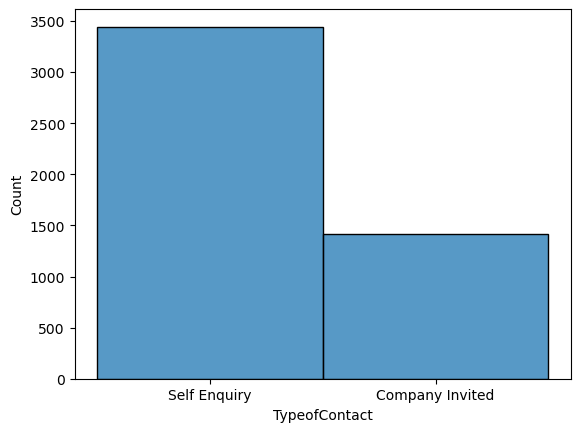

In [20]:
sns.histplot(df['TypeofContact'])

In [21]:
df.loc[df['TypeofContact'].isnull(), 'TypeofContact'] = df['TypeofContact'].mode()[0]


In [22]:
df['TypeofContact'].isnull().sum()

np.int64(0)

I replaced the missing values with the mode of TypeofContact

### DurationOfPitch

In [23]:
df.DurationOfPitch.describe()

count    4637.000000
mean       15.490835
std         8.519643
min         5.000000
25%         9.000000
50%        13.000000
75%        20.000000
max       127.000000
Name: DurationOfPitch, dtype: float64

<Axes: xlabel='DurationOfPitch', ylabel='Count'>

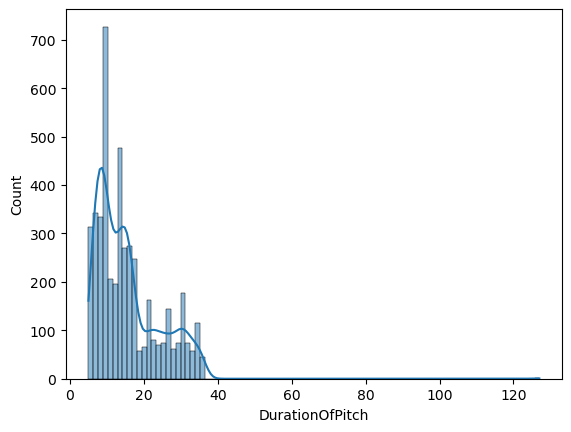

In [24]:
sns.histplot(df['DurationOfPitch'], kde = True)

In [25]:
df.loc[df['DurationOfPitch'].isnull(), 'DurationOfPitch'] = df['DurationOfPitch'].median()

In [26]:
df['DurationOfPitch'].isnull().sum()

np.int64(0)

I filled in the missing values with the median since the data was slightly skewed right

### NumberOfFollowups

In [27]:
df.NumberOfFollowups.describe()

count    4843.000000
mean        3.708445
std         1.002509
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         6.000000
Name: NumberOfFollowups, dtype: float64

<Axes: xlabel='NumberOfFollowups', ylabel='Count'>

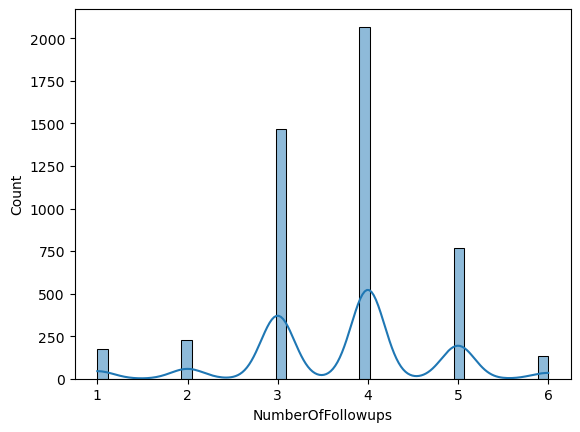

In [28]:
sns.histplot(df['NumberOfFollowups'], kde = True)

In [29]:
df['NumberOfFollowups'].skew()

np.float64(-0.37271939892913725)

In [30]:
df.loc[df['NumberOfFollowups'].isnull(), 'NumberOfFollowups'] = df['NumberOfFollowups'].median()

In [31]:
df['NumberOfFollowups'].isnull().sum()

np.int64(0)

I filled in the missing values with the median since the data was very slightly skewed left but close to normal

### PreferredPropertyStar

In [32]:
df.PreferredPropertyStar.describe()

count    4862.000000
mean        3.581037
std         0.798009
min         3.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: PreferredPropertyStar, dtype: float64

<Axes: xlabel='PreferredPropertyStar', ylabel='Count'>

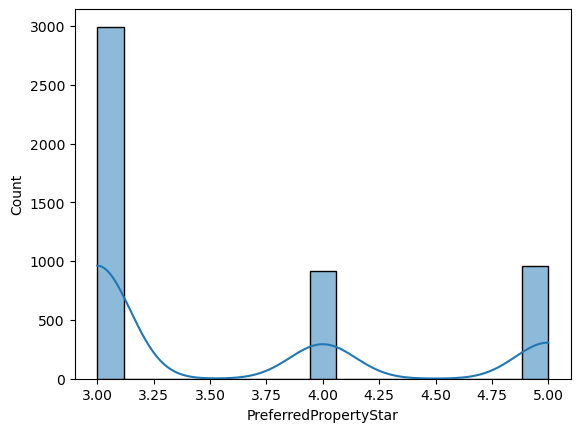

In [33]:
sns.histplot(df['PreferredPropertyStar'], kde = True)

In [34]:
df['PreferredPropertyStar'].skew()

np.float64(0.8955450954235519)

In [35]:
df.loc[df['PreferredPropertyStar'].isnull(), 'PreferredPropertyStar'] = df['PreferredPropertyStar'].median()

In [36]:
df['PreferredPropertyStar'].isnull().sum()

np.int64(0)

I filled in the missing values with the median since the data was slightly skewed right

### NumberOfTrips

In [37]:
df.NumberOfTrips.describe()

count    4748.000000
mean        3.236521
std         1.849019
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        22.000000
Name: NumberOfTrips, dtype: float64

<Axes: xlabel='NumberOfTrips', ylabel='Count'>

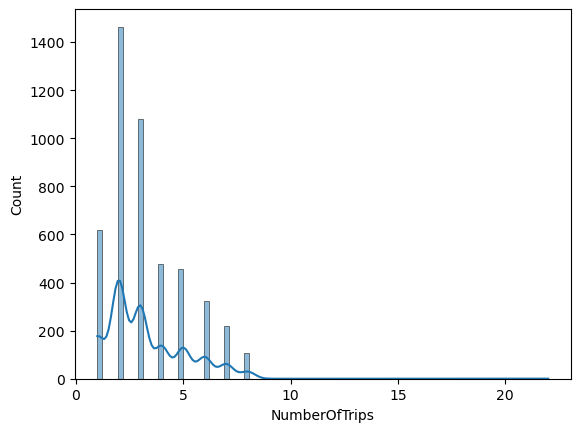

In [38]:
sns.histplot(df['NumberOfTrips'], kde = True)

In [39]:
df['NumberOfTrips'].skew()

np.float64(1.4538837843258117)

In [40]:
df.loc[df['NumberOfTrips'].isnull(), 'NumberOfTrips'] = df['NumberOfTrips'].median()

In [41]:
df['NumberOfTrips'].isnull().sum()

np.int64(0)

I filled in the missing values with the median since the data was skewed right

### NumberOfChildrenVisiting

In [42]:
df.NumberOfChildrenVisiting.describe()

count    4822.000000
mean        1.187267
std         0.857861
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: NumberOfChildrenVisiting, dtype: float64

<Axes: xlabel='NumberOfChildrenVisiting', ylabel='Count'>

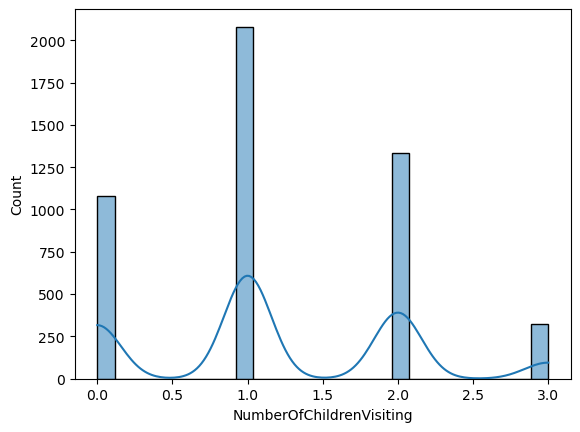

In [43]:
sns.histplot(df['NumberOfChildrenVisiting'], kde = True)

In [44]:
df['NumberOfChildrenVisiting'].skew()

np.float64(0.2721993315693236)

In [45]:
df.loc[df['NumberOfChildrenVisiting'].isnull(), 'NumberOfChildrenVisiting'] = df['NumberOfChildrenVisiting'].median()

In [46]:
df['NumberOfChildrenVisiting'].isnull().sum()

np.int64(0)

I filled in the missing values with the median since the data was slightly skewed right

### MonthlyIncome

In [47]:
df.MonthlyIncome.describe()

count     4655.000000
mean     23619.853491
std       5380.698361
min       1000.000000
25%      20346.000000
50%      22347.000000
75%      25571.000000
max      98678.000000
Name: MonthlyIncome, dtype: float64

<Axes: xlabel='MonthlyIncome', ylabel='Count'>

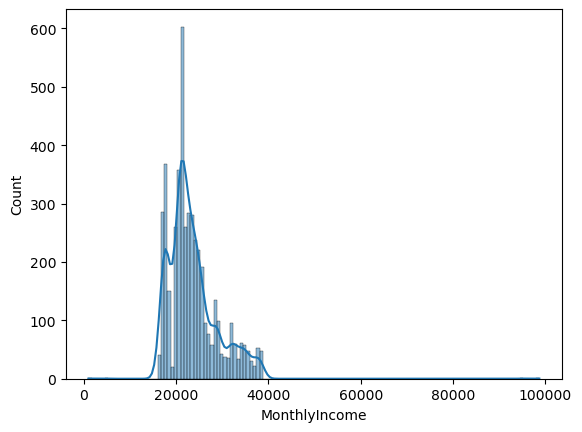

In [48]:
sns.histplot(df['MonthlyIncome'], kde = True)

In [49]:
df['MonthlyIncome'].skew()

np.float64(1.949159831766865)

In [50]:
df.loc[df['MonthlyIncome'].isnull(), 'MonthlyIncome'] = df['MonthlyIncome'].median()

In [51]:
df['MonthlyIncome'].isnull().sum()

np.int64(0)

I filled in the missing values with the median since the data was skewed right

In [52]:
df.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

All columns now have data in them

## Outliers

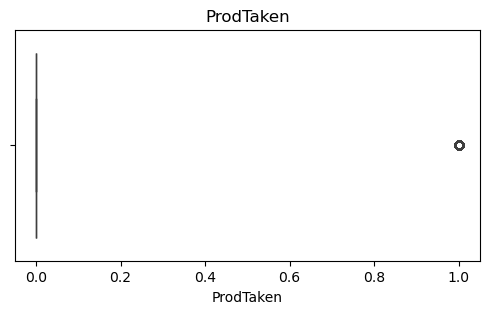

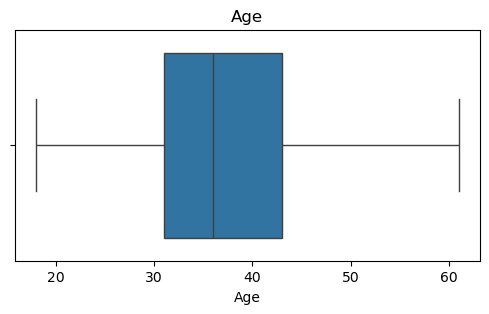

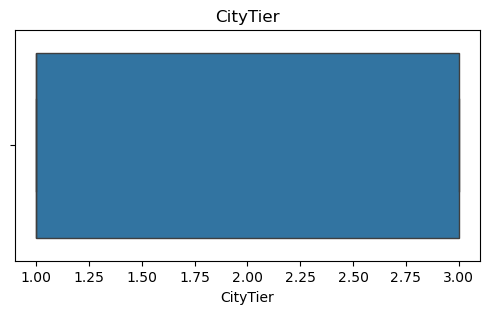

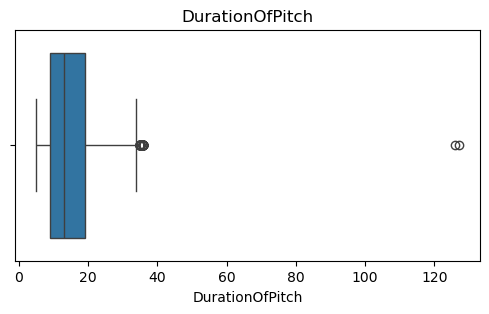

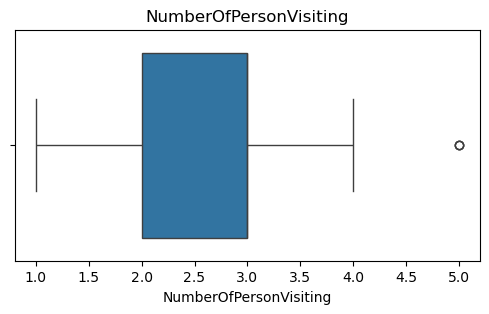

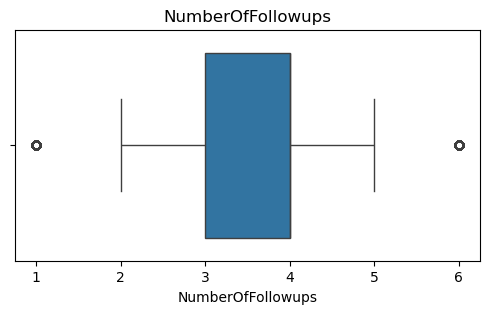

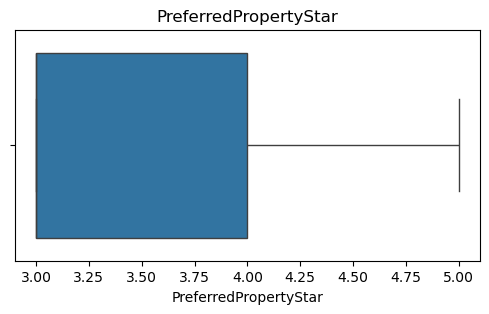

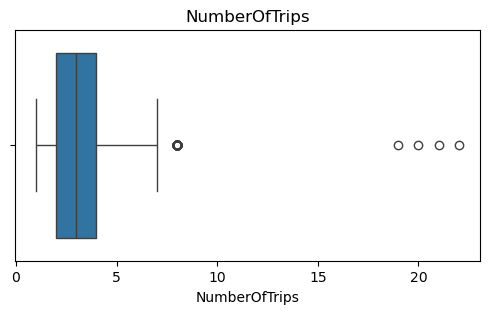

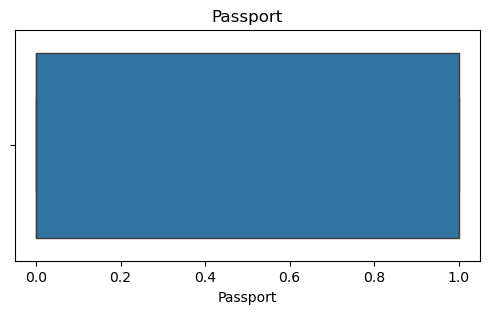

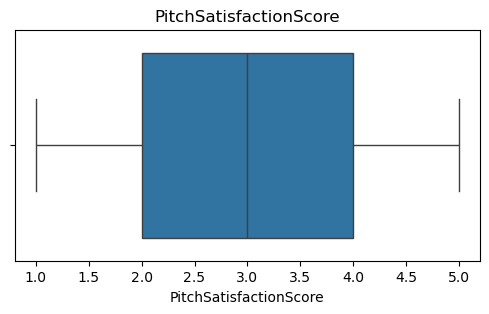

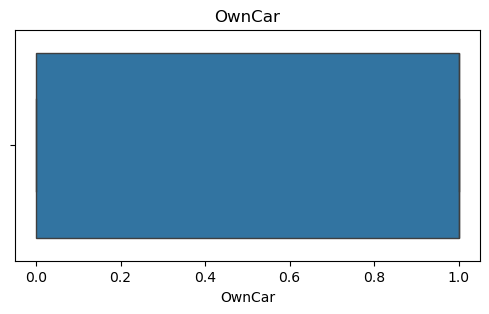

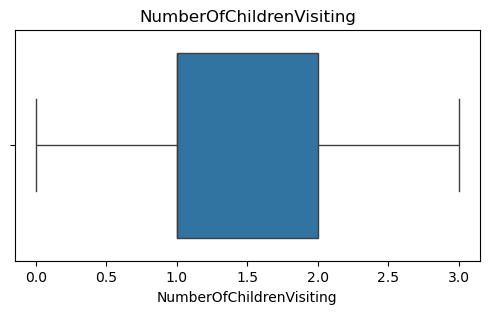

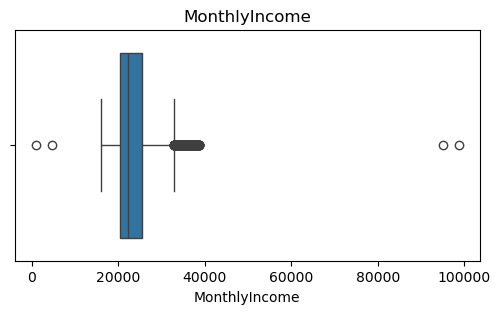

In [53]:
#Creates boxplots for each feature
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Features that need adjustment: DurationOfPitch, NumberOfPersonVisiting, NumberOfFollowups, NumberOfTrips, and MonthlyIncome

### DurationOfPitch

<Axes: xlabel='DurationOfPitch'>

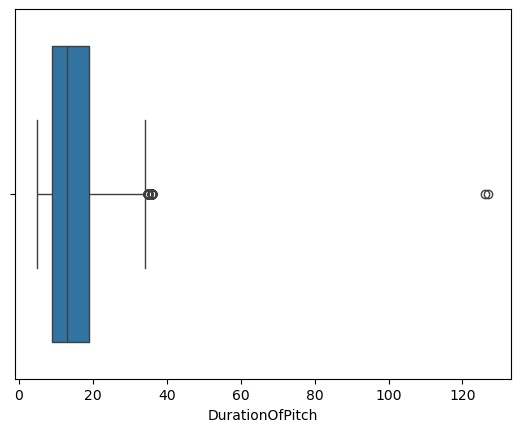

In [54]:
sns.boxplot(x=df['DurationOfPitch'])

<Axes: xlabel='DurationOfPitch', ylabel='Count'>

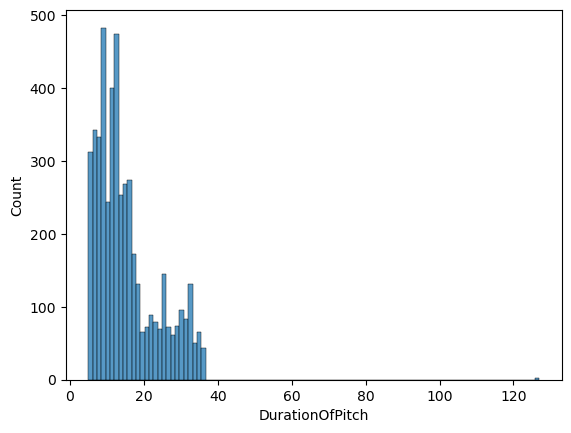

In [55]:
sns.histplot(x=df['DurationOfPitch'])

In [56]:
Q1 = df.DurationOfPitch.quantile(0.25)
Q3 = df.DurationOfPitch.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df.loc[df.DurationOfPitch > upper_bound, 'DurationOfPitch'] = upper_bound

<Axes: xlabel='DurationOfPitch'>

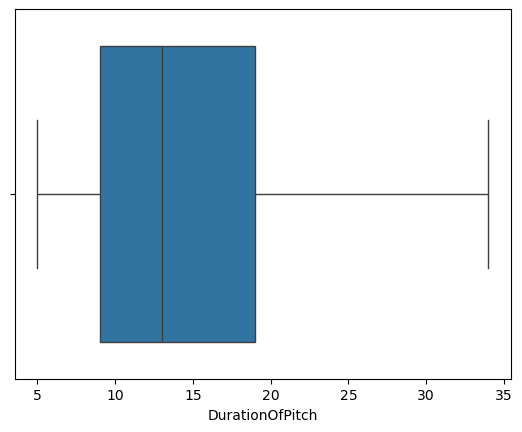

In [57]:
sns.boxplot(x=df['DurationOfPitch'])

For the outliers above the upper bound, I put them equal to the upper bound as some values could've made sense while a few would throw our model off.

### NumberOfPersonVisiting

<Axes: xlabel='NumberOfPersonVisiting'>

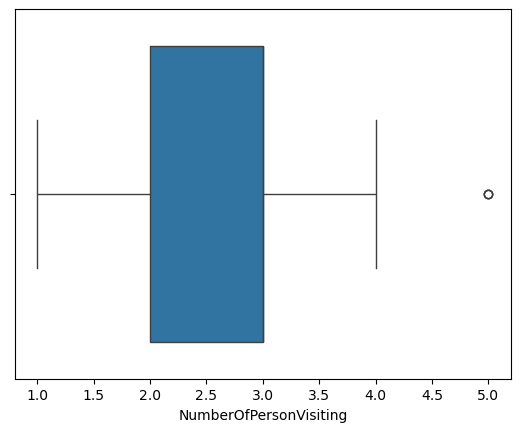

In [58]:
sns.boxplot(x=df['NumberOfPersonVisiting'])

I am leaving this outlier as it is completely reasonable and not to far from our data

### NumberOfFollowups

In [59]:
df['NumberOfFollowups'].value_counts()

NumberOfFollowups
4.0    2113
3.0    1466
5.0     768
2.0     229
1.0     176
6.0     136
Name: count, dtype: int64

<Axes: xlabel='NumberOfFollowups'>

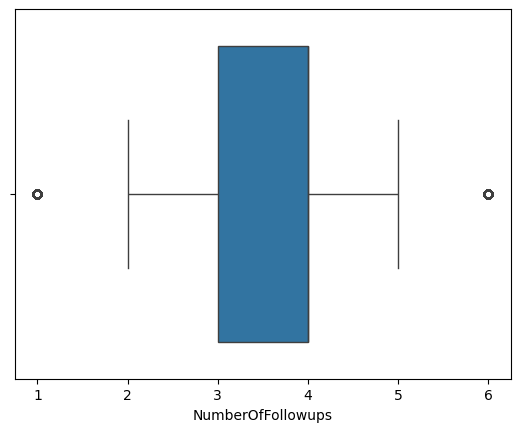

In [60]:
sns.boxplot(x=df['NumberOfFollowups'])

With the small range and the fact that the outliers only make up about 6% of the total data, I'm also going to keep these outliers. 

### NumberOfTrips

In [61]:
df['NumberOfTrips'].value_counts()

NumberOfTrips
2.0     1464
3.0     1219
1.0      620
4.0      478
5.0      458
6.0      322
7.0      218
8.0      105
19.0       1
21.0       1
20.0       1
22.0       1
Name: count, dtype: int64

<Axes: xlabel='NumberOfTrips'>

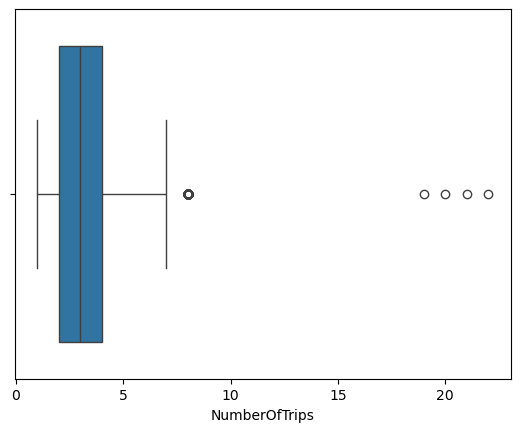

In [62]:
sns.boxplot(x=df['NumberOfTrips'])

In [63]:
upper_cap = 8
df.loc[df['NumberOfTrips'] > upper_cap, 'NumberOfTrips'] = upper_cap

<Axes: xlabel='NumberOfTrips'>

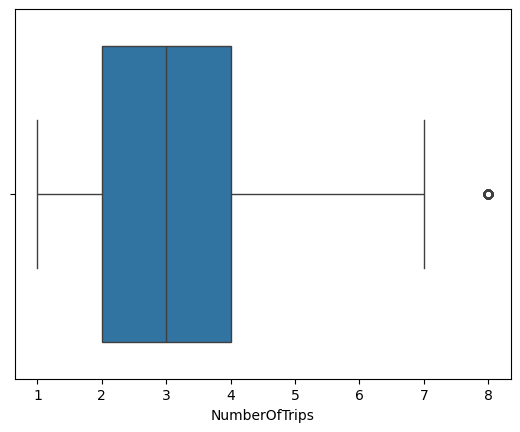

In [64]:
sns.boxplot(x=df['NumberOfTrips'])

I pulled the more significant outliers in to the values that were held in 8. I did this because the values in 8 aren't far from our spread and represent about 2% of the data so I think having those values is important

### MonthlyIncome

In [65]:
df.loc[df['MonthlyIncome'] > 40000, 'MonthlyIncome'].value_counts()

MonthlyIncome
95000.0    1
98678.0    1
Name: count, dtype: int64

<Axes: xlabel='MonthlyIncome'>

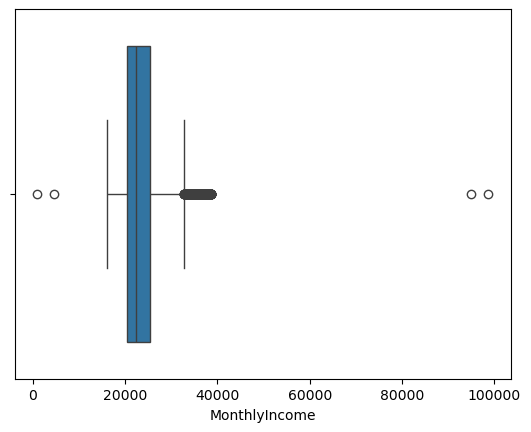

In [66]:
sns.boxplot(x=df['MonthlyIncome'])

In [67]:
upper_cap= 39000
df.loc[df['MonthlyIncome'] > upper_cap, 'MonthlyIncome'] = upper_cap

In [68]:
Q1 = df.MonthlyIncome.quantile(0.25)
Q3 = df.MonthlyIncome.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

df.loc[df.MonthlyIncome < lower_bound, 'MonthlyIncome'] = lower_bound

<Axes: xlabel='MonthlyIncome'>

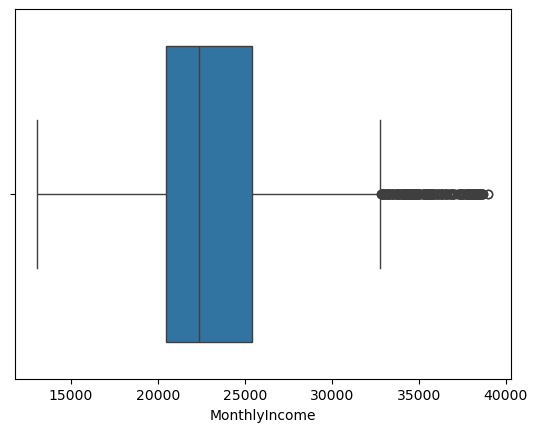

In [69]:
sns.boxplot(x=df['MonthlyIncome'])

Many values between 35000 and 39000 are outliers, so I want to keep those, but remove the big outliers like the ones near 100000. I set an upper cap of 39000 and set the lower outliers to the lower bound. Those outliers between 35000 and 39000 don't appear to be true anomalies as they could happen.

## Inconsistent Data

In [70]:
df.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups',
       'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [71]:
df['ProdTaken'].unique()

array([1, 0])

In [72]:
df['Age'].unique()

array([41., 49., 37., 33., 36., 32., 59., 30., 38., 35., 31., 34., 28.,
       29., 22., 53., 21., 42., 44., 46., 39., 24., 43., 50., 27., 26.,
       48., 55., 45., 56., 23., 51., 40., 54., 58., 20., 25., 19., 57.,
       52., 47., 18., 60., 61.])

In [73]:
df['TypeofContact'].unique()

array(['Self Enquiry', 'Company Invited'], dtype=object)

In [74]:
df['CityTier'].unique()

array([3, 1, 2])

In [75]:
df['DurationOfPitch'].unique()

array([ 6., 14.,  8.,  9., 30., 29., 33., 22., 21., 32., 25., 27., 11.,
       17., 15., 13., 12., 16., 10., 31., 18., 24., 34., 28., 20., 26.,
       23.,  5., 19.,  7.])

In [76]:
df['Occupation'].unique()

array(['Salaried', 'Free Lancer', 'Small Business', 'Large Business'],
      dtype=object)

In [77]:
df['Gender'].unique()

array(['Female', 'Male', 'Fe Male'], dtype=object)

In [78]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [79]:
df.loc[df['Gender'] == 'Fe Male', 'Gender'] = 'Female'

In [80]:
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [81]:
df['NumberOfPersonVisiting'].unique()

array([3, 2, 1, 4, 5])

In [82]:
df['NumberOfFollowups'].unique()

array([3., 4., 2., 5., 1., 6.])

In [83]:
df['ProductPitched'].unique()

array(['Deluxe', 'Basic', 'Standard', 'Super Deluxe', 'King'],
      dtype=object)

In [84]:
df['PreferredPropertyStar'].unique()

array([3., 4., 5.])

In [85]:
df['MaritalStatus'].unique()

array(['Single', 'Divorced', 'Married', 'Unmarried'], dtype=object)

In [86]:
df['NumberOfTrips'].unique()

array([1., 2., 7., 5., 6., 3., 4., 8.])

In [87]:
df['Passport'].unique()

array([1, 0])

In [88]:
df['PitchSatisfactionScore'].unique()

array([2, 3, 5, 4, 1])

In [89]:
df['OwnCar'].unique()

array([1, 0])

In [90]:
df['NumberOfChildrenVisiting'].unique()

array([0., 2., 1., 3.])

In [91]:
df['Designation'].unique()

array(['Manager', 'Executive', 'Senior Manager', 'AVP', 'VP'],
      dtype=object)

In [92]:
df['MonthlyIncome'].unique()

array([20993., 20130., 17090., ..., 22097., 22995., 21471.], shape=(2473,))

All I adjusted was an incorrect spelling of female but other than that everything seems normal

# Exploratory Data Analysis

In [93]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [94]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the feature - number of rows
    count = data[feature].nunique() # unique values of the feature
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [95]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique() # unique values of the feature
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 115)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    print(tab)
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

## Univariate EDA

In [96]:
df.dtypes

ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

### Explore Categorical Features

Occupation, Gender, ProductPitched, MaritalStatus, Designation

#### TypeofContact

In [97]:
df['TypeofContact'].describe()

count             4888
unique               2
top       Self Enquiry
freq              3469
Name: TypeofContact, dtype: object

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


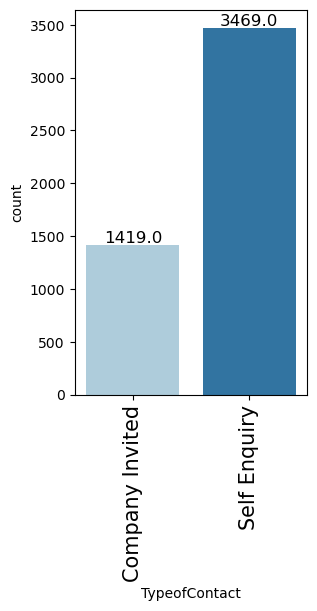

In [98]:
labeled_barplot(df, 'TypeofContact')

Observation:
- over twice as many people were self-enquired than there were company invited 

#### Occupation

In [99]:
df['Occupation'].describe()

count         4888
unique           4
top       Salaried
freq          2368
Name: Occupation, dtype: object

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


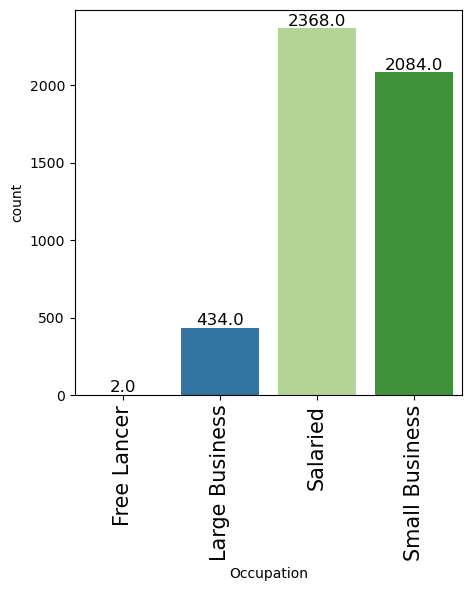

In [100]:
labeled_barplot(df, 'Occupation')

Observation:
- Majority of people have either a salaried or small business occupation
- Very few Free lancers and Large business occupations

#### Gender

In [101]:
df['Gender'].describe()

count     4888
unique       2
top       Male
freq      2916
Name: Gender, dtype: object

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


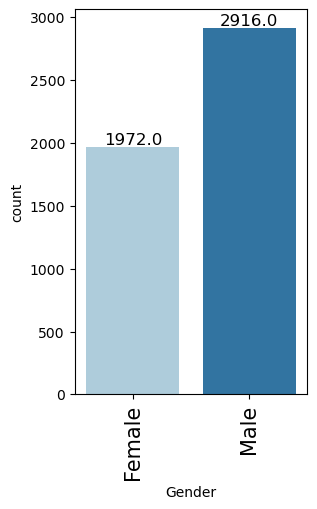

In [102]:
labeled_barplot(df, 'Gender')

Observation:
- More males than females 

#### ProductPitched

In [103]:
df['ProductPitched'].describe()

count      4888
unique        5
top       Basic
freq       1842
Name: ProductPitched, dtype: object

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


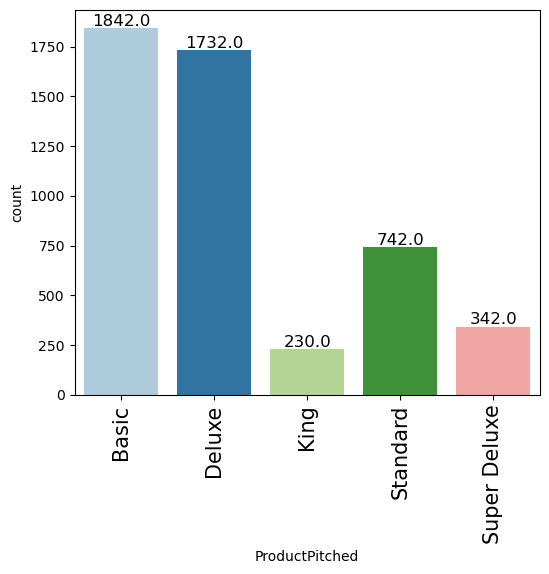

In [104]:
labeled_barplot(df, 'ProductPitched')

Observation:
- Most salesmen pitch either basic or deluxe products

#### MaritalStatus

In [105]:
df['MaritalStatus'].describe()

count        4888
unique          4
top       Married
freq         2340
Name: MaritalStatus, dtype: object

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


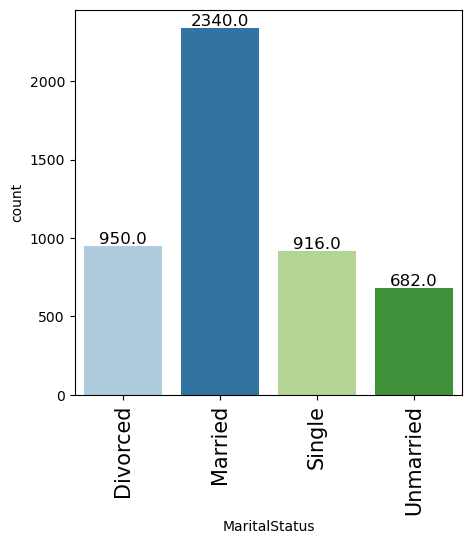

In [106]:
labeled_barplot(df, 'MaritalStatus')

Observation:
- Its about split between married and non married
- Can group these

In [107]:
df['MaritalStatus_Grouped'] = df['MaritalStatus'].replace({
    'Married': 'Married',
    'Single': 'Not Married',
    'Unmarried': 'Not Married',
    'Divorced': 'Not Married'
})

In [108]:
df = df.drop('MaritalStatus', axis=1)

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


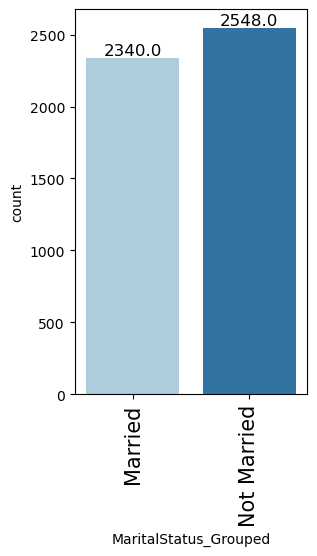

In [109]:
labeled_barplot(df, 'MaritalStatus_Grouped')

#### Designation

In [110]:
df['Designation'].describe()

count          4888
unique            5
top       Executive
freq           1842
Name: Designation, dtype: object

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


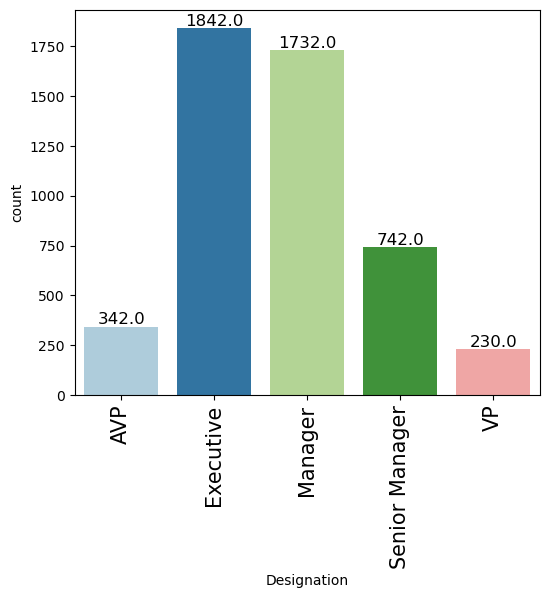

In [111]:
labeled_barplot(df, 'Designation')

Observation:
- Mainly Executive and Manager Roles
- AVP and VP have the fewest 

### Explore Numeric Features

#### ProdTaken

In [112]:
df['ProdTaken'].describe()

count    4888.000000
mean        0.188216
std         0.390925
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: ProdTaken, dtype: float64

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


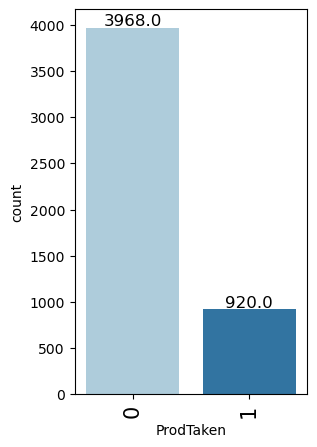

In [113]:
labeled_barplot(df, 'ProdTaken')

Observation:
Only about 20% of people bought the product

#### Age

In [114]:
df['Age'].describe()

count    4888.000000
mean       37.547259
std         9.104795
min        18.000000
25%        31.000000
50%        36.000000
75%        43.000000
max        61.000000
Name: Age, dtype: float64

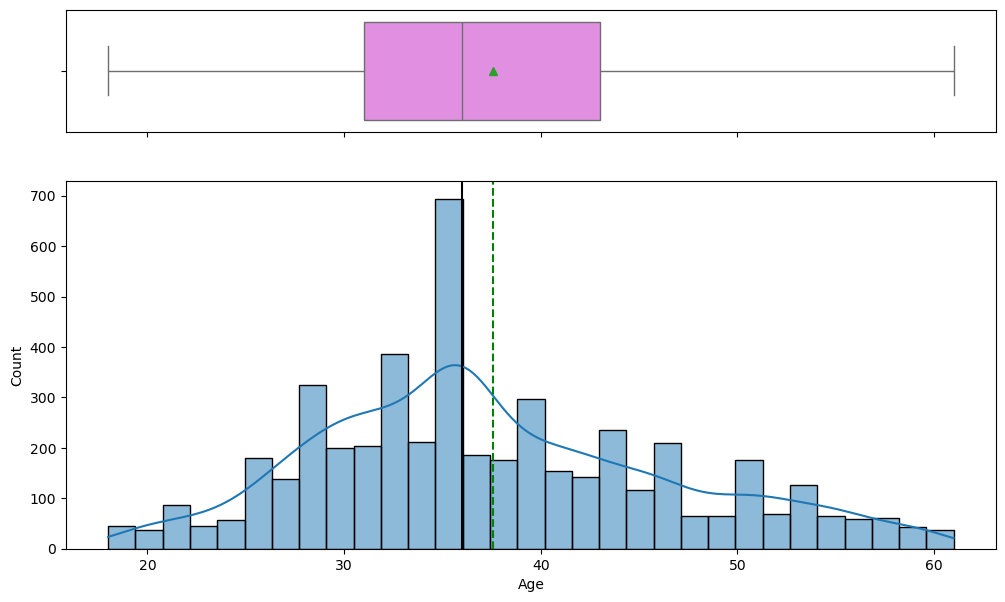

In [115]:
histogram_boxplot(df, 'Age',kde=True)

Observations:
- Pretty normal distrubution 
- mean : 37.5
- median : 36

#### CityTier

In [116]:
df['CityTier'].describe()

count    4888.000000
mean        1.654255
std         0.916583
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max         3.000000
Name: CityTier, dtype: float64

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


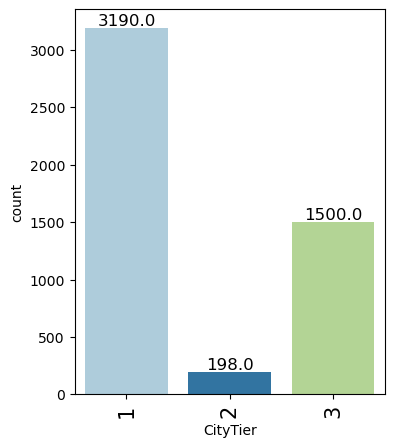

In [117]:
labeled_barplot(df, 'CityTier')

Observation:
- Most people are from City Tier 1 (More Wealthy?)

#### DurationOfPitch

In [118]:
df['DurationOfPitch'].describe()

count    4888.000000
mean       15.293576
std         7.938320
min         5.000000
25%         9.000000
50%        13.000000
75%        19.000000
max        34.000000
Name: DurationOfPitch, dtype: float64

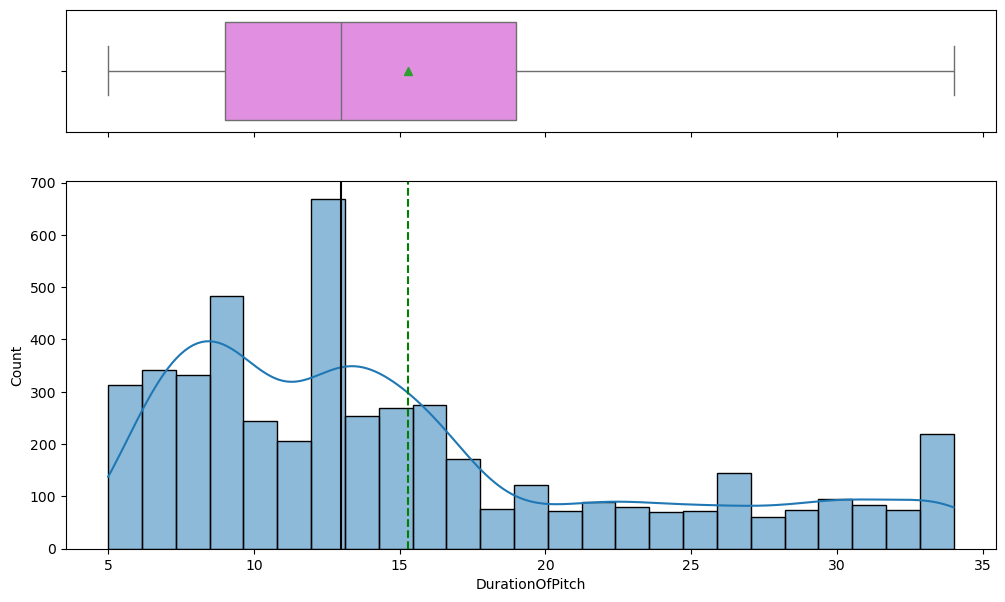

In [119]:
histogram_boxplot(df, 'DurationOfPitch',kde=True)

Observation:
mean: 15.2
median: 13
slightly skewed to the right

#### NumberOfPersonVisiting

In [120]:
df['NumberOfPersonVisiting'].describe()

count    4888.000000
mean        2.905074
std         0.724891
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         5.000000
Name: NumberOfPersonVisiting, dtype: float64

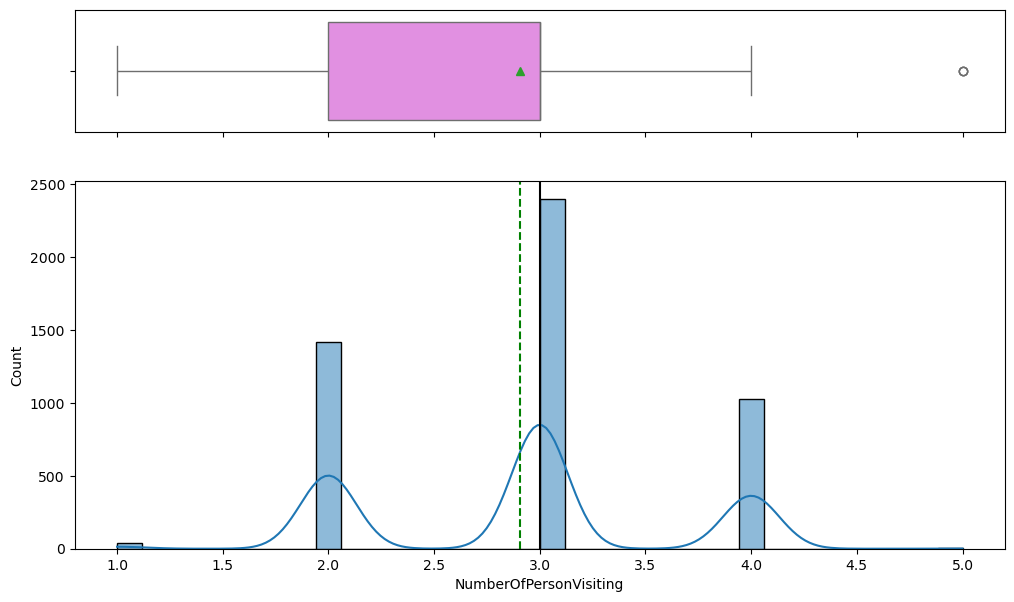

In [121]:
histogram_boxplot(df, 'NumberOfPersonVisiting',kde=True)

Observation
mean: 2.9
median: 3
pretty normal distrubution

#### NumberOfFollowups

In [122]:
df['NumberOfFollowups'].describe()

count    4888.000000
mean        3.711129
std         0.998271
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         6.000000
Name: NumberOfFollowups, dtype: float64

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


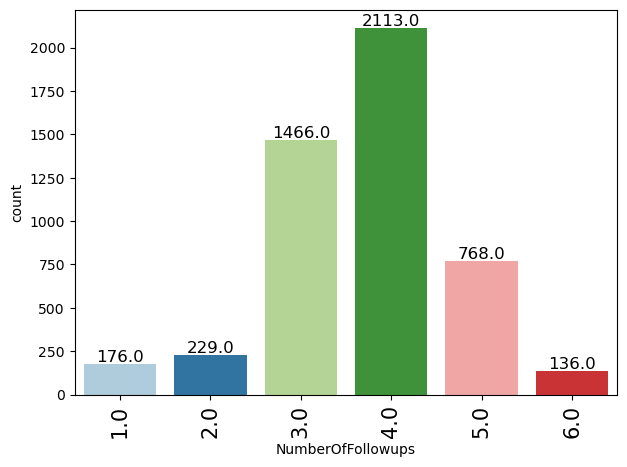

In [123]:
labeled_barplot(df, 'NumberOfFollowups')

Observation:
Most sales people did 4 follow ups

#### PreferredPropertyStar

In [124]:
df['PreferredPropertyStar'].describe()

count    4888.000000
mean        3.577946
std         0.797005
min         3.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: PreferredPropertyStar, dtype: float64

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


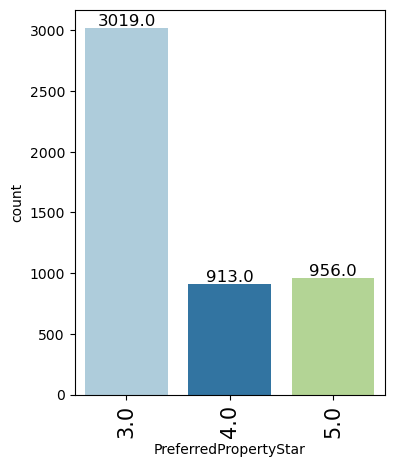

In [125]:
labeled_barplot(df, 'PreferredPropertyStar')

Observation:
The prefered hotel rating is a 3 which is a bit odd but maybe its an at least 3 star

#### NumberOfTrips

In [126]:
df['NumberOfTrips'].describe()

count    4888.000000
mean        3.219517
std         1.759505
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         8.000000
Name: NumberOfTrips, dtype: float64

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


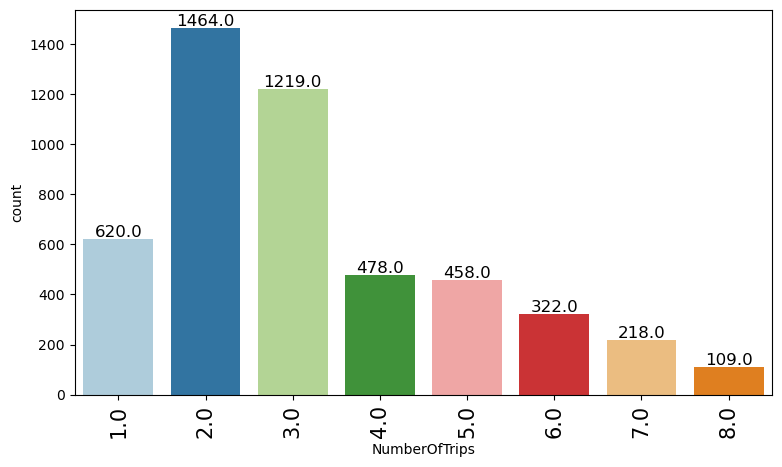

In [127]:
labeled_barplot(df, 'NumberOfTrips')

Observation:
Most people go on trips twice a year

#### Passport

In [128]:
df['Passport'].describe()

count    4888.000000
mean        0.290917
std         0.454232
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Passport, dtype: float64

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


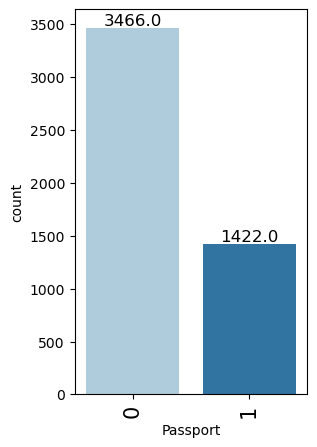

In [129]:
labeled_barplot(df, 'Passport')

Observation:
Most people dont have a passport

#### PitchSatisfactionScore

In [130]:
df['PitchSatisfactionScore'].describe()

count    4888.000000
mean        3.078151
std         1.365792
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: PitchSatisfactionScore, dtype: float64

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


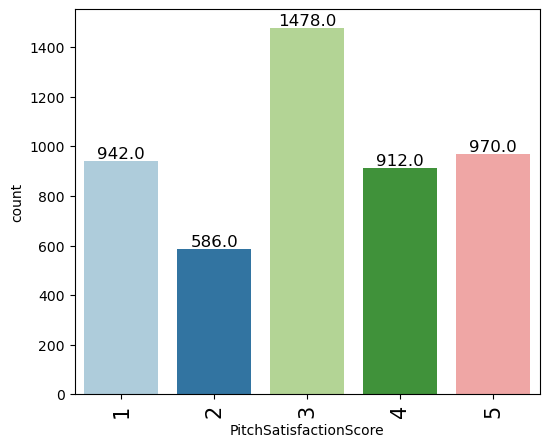

In [131]:
labeled_barplot(df, 'PitchSatisfactionScore')

Observation:
Most have a pitch satisfaction score of 3

#### OwnCar

In [132]:
df['OwnCar'].describe()

count    4888.000000
mean        0.620295
std         0.485363
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: OwnCar, dtype: float64

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


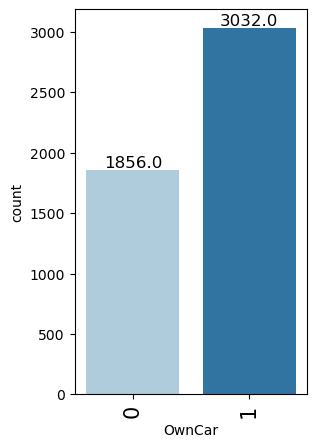

In [133]:
labeled_barplot(df, 'OwnCar')

Observation:
Most People have a car but there's a surprising amount that don't however could be due to location

#### NumberOfChildrenVisiting

In [134]:
df['NumberOfChildrenVisiting'].describe()

count    4888.000000
mean        1.184738
std         0.852323
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: NumberOfChildrenVisiting, dtype: float64

C:\Users\fords\AppData\Local\Temp\ipykernel_13652\790638548.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


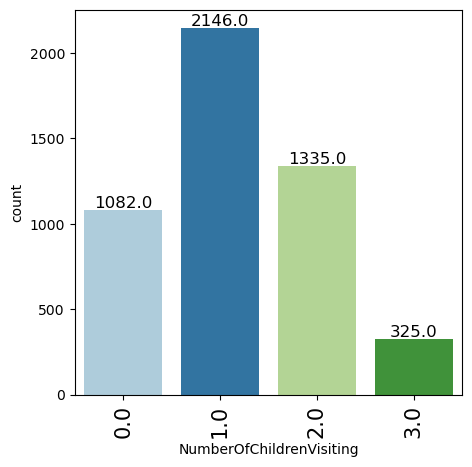

In [135]:
labeled_barplot(df, 'NumberOfChildrenVisiting')

Observation:
Many people have kids who are younger than 5 years old that they would have to take with them

#### MonthlyIncome

In [136]:
df['MonthlyIncome'].describe()

count     4888.000000
mean     23539.702077
std       5040.951064
min      13075.375000
25%      20485.000000
50%      22347.000000
75%      25424.750000
max      39000.000000
Name: MonthlyIncome, dtype: float64

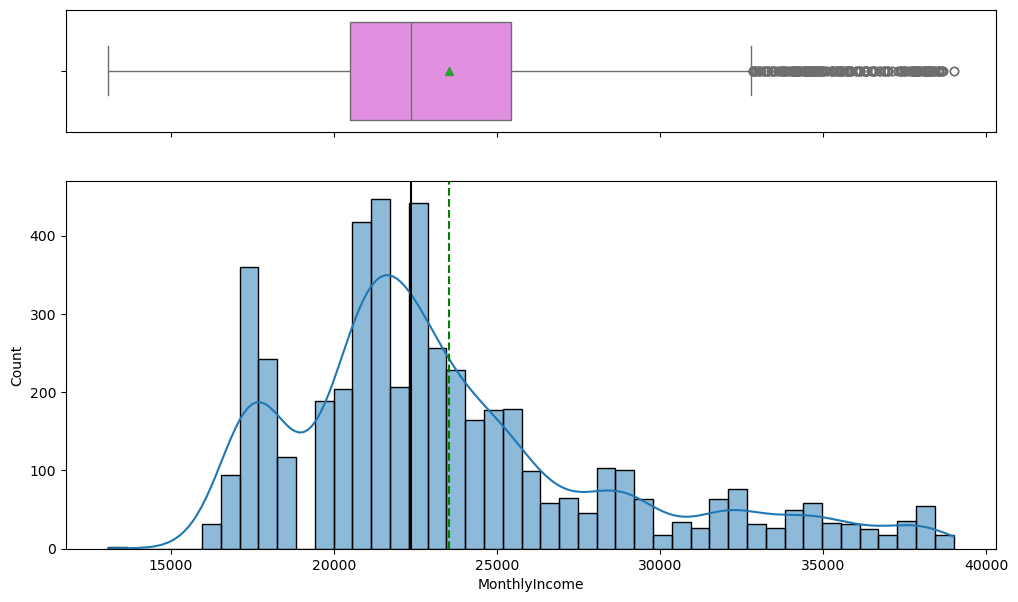

In [137]:
histogram_boxplot(df, 'MonthlyIncome',kde=True)

Observation:
mean:23539
median: 22347

## Bivariate EDA

### Correlated Features

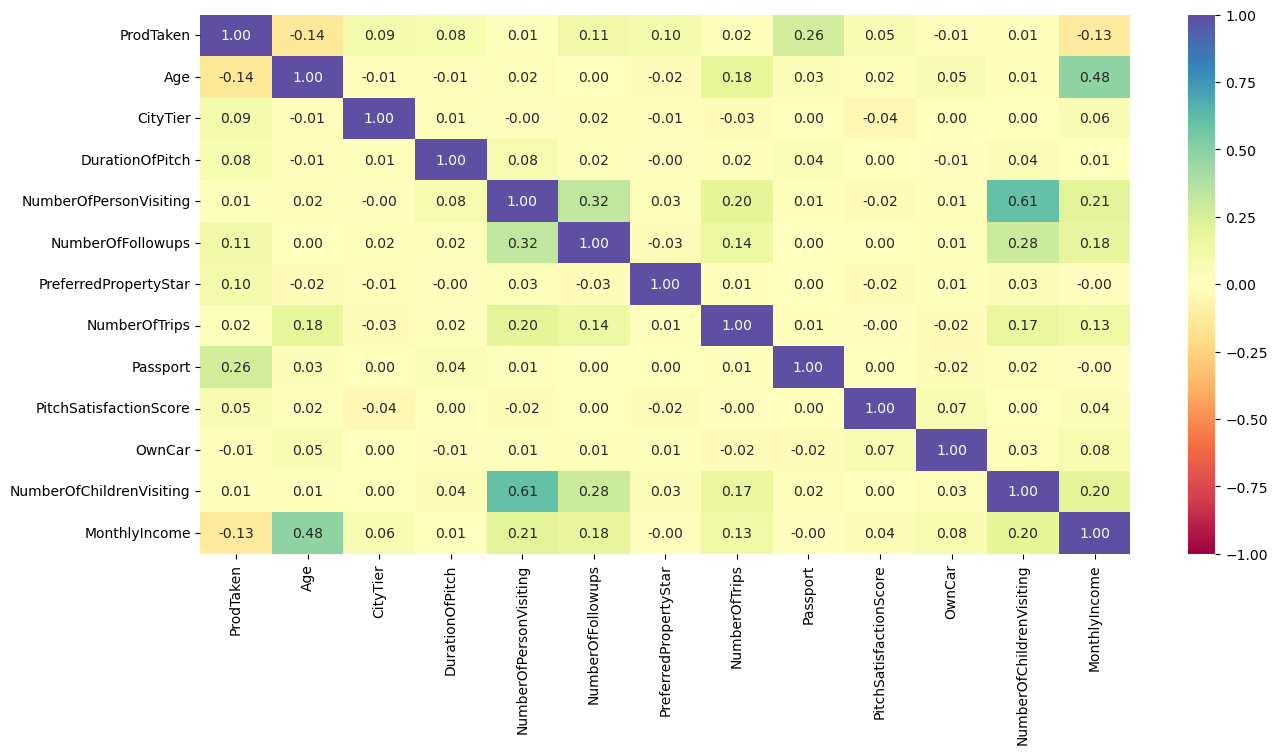

In [138]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

Higher correlated:
- Age and MonthlyIncome
- NumberOfPersonVisiting and NumberOfChildrenVisiting
- NumberOfPersonVisiting and NumberOfFollowups

### Categorical

#### TypeofContact

ProdTaken           0    1   All
TypeofContact                   
All              3968  920  4888
Self Enquiry     2859  610  3469
Company Invited  1109  310  1419
-------------------------------------------------------------------------------------------------------------------
ProdTaken               0         1
TypeofContact                      
Company Invited  0.781536  0.218464
Self Enquiry     0.824157  0.175843


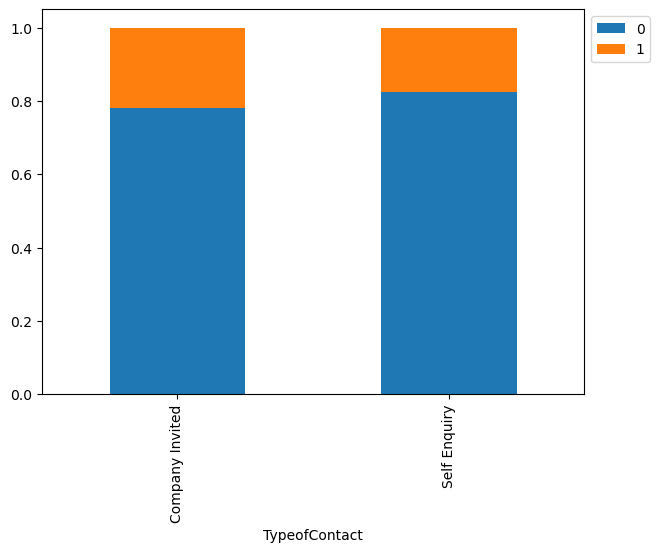

In [139]:
stacked_barplot(df, 'TypeofContact', 'ProdTaken')

Observation:
Not much correlation to TypeofContact

#### Occupation

ProdTaken          0    1   All
Occupation                     
All             3968  920  4888
Salaried        1954  414  2368
Small Business  1700  384  2084
Large Business   314  120   434
Free Lancer        0    2     2
-------------------------------------------------------------------------------------------------------------------
ProdTaken              0         1
Occupation                        
Free Lancer     0.000000  1.000000
Large Business  0.723502  0.276498
Small Business  0.815739  0.184261
Salaried        0.825169  0.174831


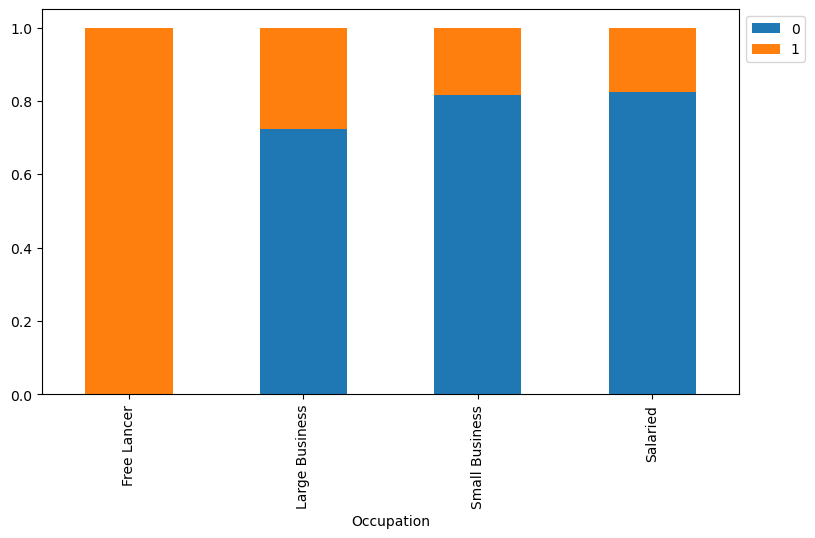

In [140]:
stacked_barplot(df, 'Occupation', 'ProdTaken')

Observation:
The two free lancers bought the product but would need a bigger sample size of free lancers to make a solid statement. Large Businesses have the most bought otherwise

#### Gender

ProdTaken     0    1   All
Gender                    
All        3968  920  4888
Male       2338  578  2916
Female     1630  342  1972
-------------------------------------------------------------------------------------------------------------------
ProdTaken         0         1
Gender                       
Male       0.801783  0.198217
Female     0.826572  0.173428


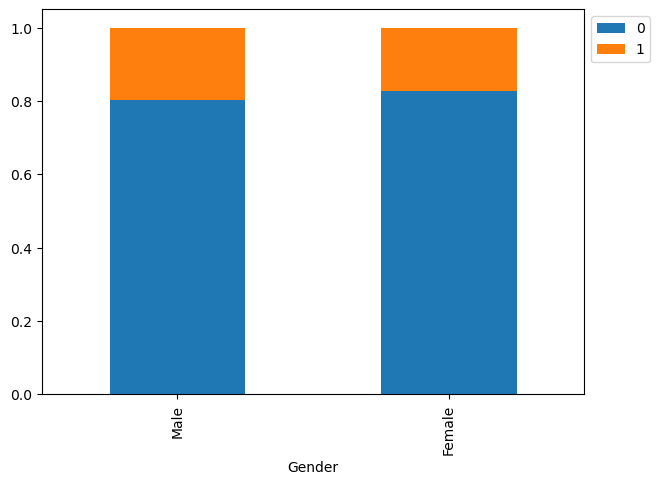

In [141]:
stacked_barplot(df, 'Gender', 'ProdTaken')

Observation:
Not Not much correlation to Gender

#### ProductPitched

ProdTaken          0    1   All
ProductPitched                 
All             3968  920  4888
Basic           1290  552  1842
Deluxe          1528  204  1732
Standard         618  124   742
King             210   20   230
Super Deluxe     322   20   342
-------------------------------------------------------------------------------------------------------------------
ProdTaken              0         1
ProductPitched                    
Basic           0.700326  0.299674
Standard        0.832884  0.167116
Deluxe          0.882217  0.117783
King            0.913043  0.086957
Super Deluxe    0.941520  0.058480


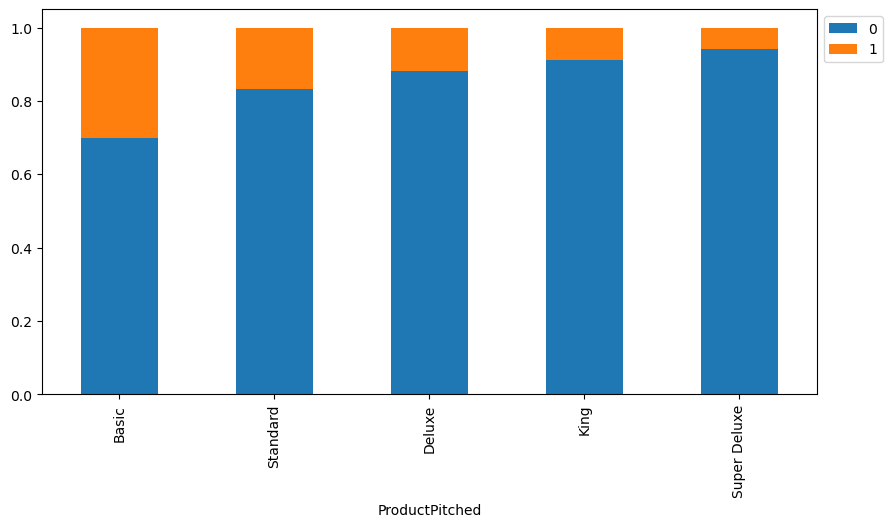

In [142]:
stacked_barplot(df, 'ProductPitched', 'ProdTaken')

Observation:
The more basic the product is the more sales. However Basic and Deluxe had the most pitched.

#### MaritalStatus

ProdTaken                 0    1   All
MaritalStatus_Grouped                 
All                    3968  920  4888
Not Married            1954  594  2548
Married                2014  326  2340
-------------------------------------------------------------------------------------------------------------------
ProdTaken                     0         1
MaritalStatus_Grouped                    
Not Married            0.766876  0.233124
Married                0.860684  0.139316


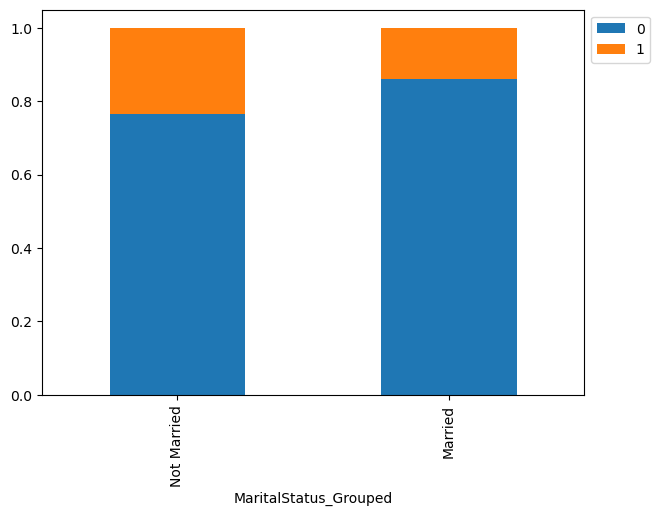

In [143]:
stacked_barplot(df, 'MaritalStatus_Grouped', 'ProdTaken')

Observation:
More unmarried individuals purchased the product

#### Designation

ProdTaken          0    1   All
Designation                    
All             3968  920  4888
Executive       1290  552  1842
Manager         1528  204  1732
Senior Manager   618  124   742
AVP              322   20   342
VP               210   20   230
-------------------------------------------------------------------------------------------------------------------
ProdTaken              0         1
Designation                       
Executive       0.700326  0.299674
Senior Manager  0.832884  0.167116
Manager         0.882217  0.117783
VP              0.913043  0.086957
AVP             0.941520  0.058480


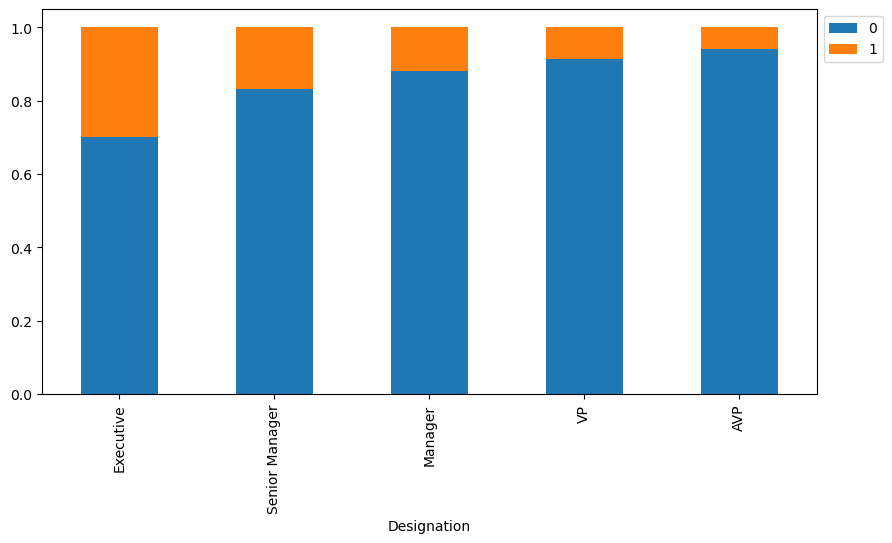

In [144]:
stacked_barplot(df, 'Designation', 'ProdTaken')

Observation:
People with a higher role tend to purchase product

### Numerical

#### Age

ProdTaken     0    1   All
Age                       
All        3968  920  4888
36.0        386   71   457
29.0        121   57   178
30.0        151   48   199
34.0        167   44   211
31.0        162   41   203
33.0        149   40   189
32.0        157   40   197
26.0         69   37   106
35.0        203   34   237
27.0        108   30   138
28.0        121   26   147
20.0         13   25    38
41.0        131   24   155
37.0        161   24   185
40.0        123   23   146
21.0         18   23    41
19.0         11   21    32
25.0         54   20    74
42.0        122   20   142
24.0         38   18    56
45.0         98   18   116
44.0         88   17   105
51.0         73   17    90
38.0        161   15   176
22.0         31   15    46
39.0        136   14   150
52.0         54   14    68
23.0         33   13    46
47.0         76   12    88
56.0         46   12    58
50.0         74   12    86
59.0         32   12    44
58.0         20   11    31
48.0         54   11    65
4

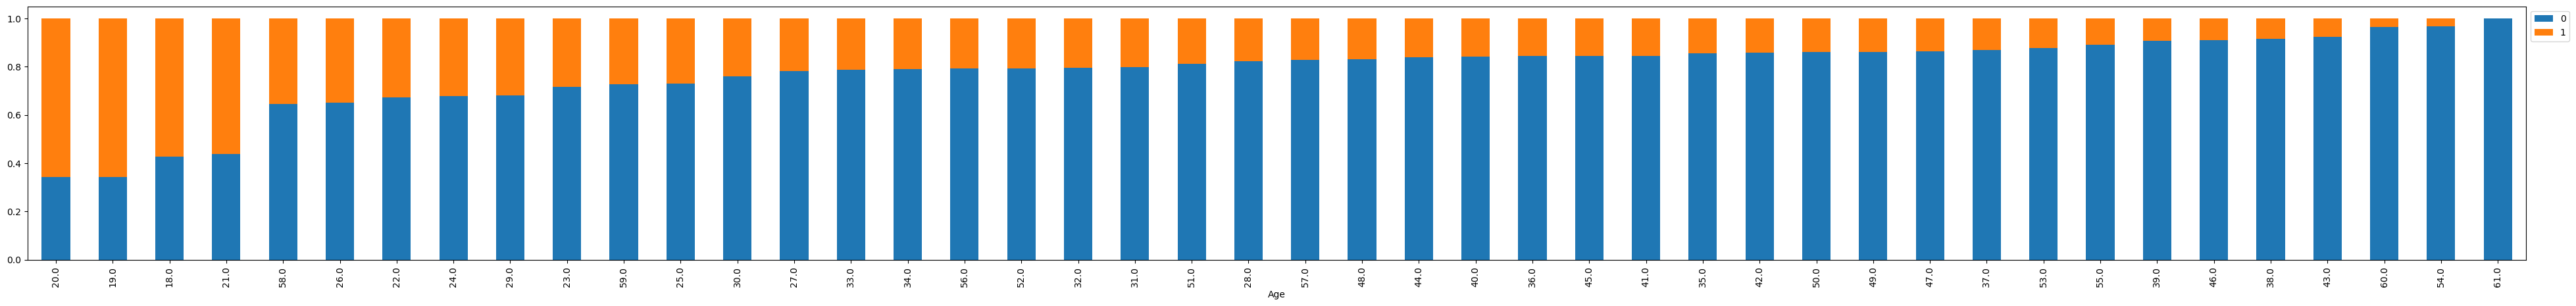

In [145]:
stacked_barplot(df, 'Age', 'ProdTaken')

Observation:
The younger someone is, the more likely to buy the product

#### CityTier

ProdTaken     0    1   All
CityTier                  
All        3968  920  4888
1          2670  520  3190
3          1146  354  1500
2           152   46   198
-------------------------------------------------------------------------------------------------------------------
ProdTaken         0         1
CityTier                     
3          0.764000  0.236000
2          0.767677  0.232323
1          0.836991  0.163009


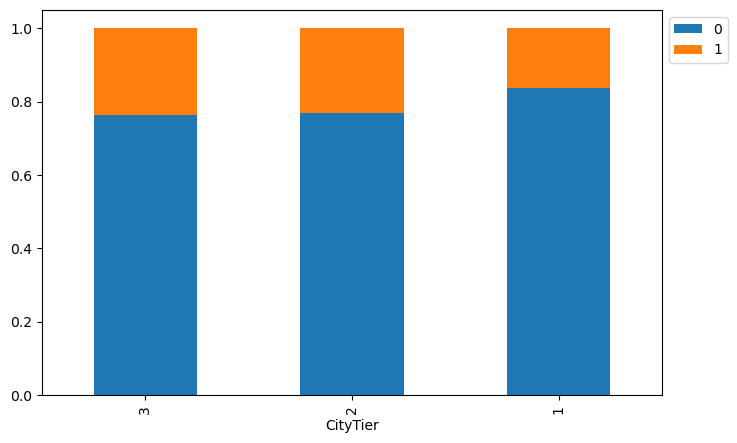

In [146]:
stacked_barplot(df, 'CityTier', 'ProdTaken')

Observation:
Doesn't seem to have much correlation

#### DurationOfPitch

ProdTaken           0    1   All
DurationOfPitch                 
All              3968  920  4888
9.0               404   79   483
13.0              397   77   474
8.0               273   60   333
16.0              218   56   274
15.0              217   52   269
7.0               294   48   342
10.0              199   45   244
14.0              212   41   253
6.0               268   39   307
11.0              168   37   205
12.0              162   33   195
31.0               52   31    83
30.0               65   30    95
34.0              133   29   162
17.0              148   24   172
22.0               66   23    89
29.0               53   21    74
19.0               36   21    57
23.0               58   21    79
20.0               46   19    65
18.0               56   19    75
28.0               44   17    61
24.0               54   16    70
21.0               57   16    73
32.0               59   15    74
27.0               58   14    72
25.0               59   14    73
26.0      

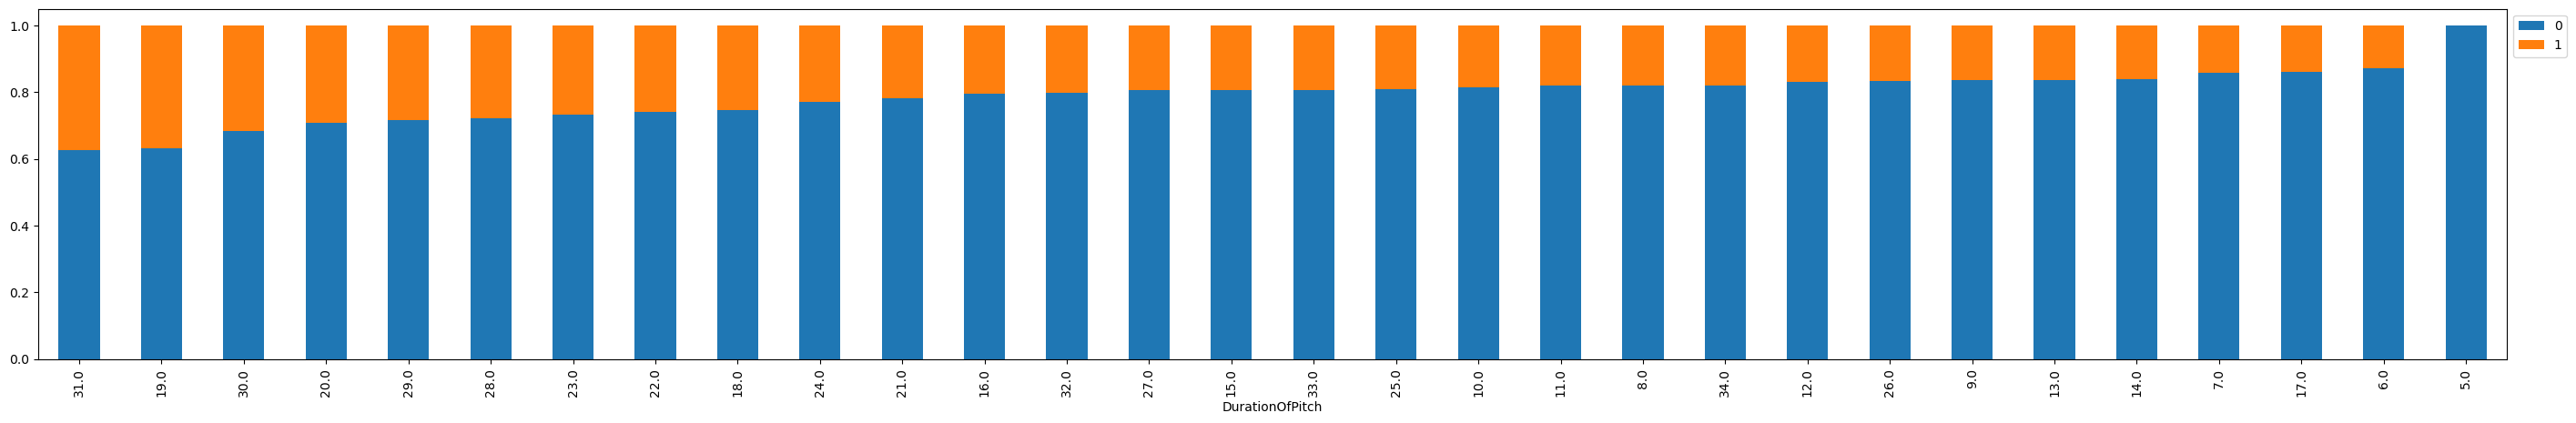

In [147]:
stacked_barplot(df, 'DurationOfPitch', 'ProdTaken')

Observation:
The shorter the pitch the more likely to get a sale

#### NumberOfPersonVisiting

ProdTaken                  0    1   All
NumberOfPersonVisiting                 
All                     3968  920  4888
3                       1942  460  2402
2                       1151  267  1418
4                        833  193  1026
1                         39    0    39
5                          3    0     3
-------------------------------------------------------------------------------------------------------------------
ProdTaken                      0         1
NumberOfPersonVisiting                    
3                       0.808493  0.191507
2                       0.811707  0.188293
4                       0.811891  0.188109
1                       1.000000  0.000000
5                       1.000000  0.000000


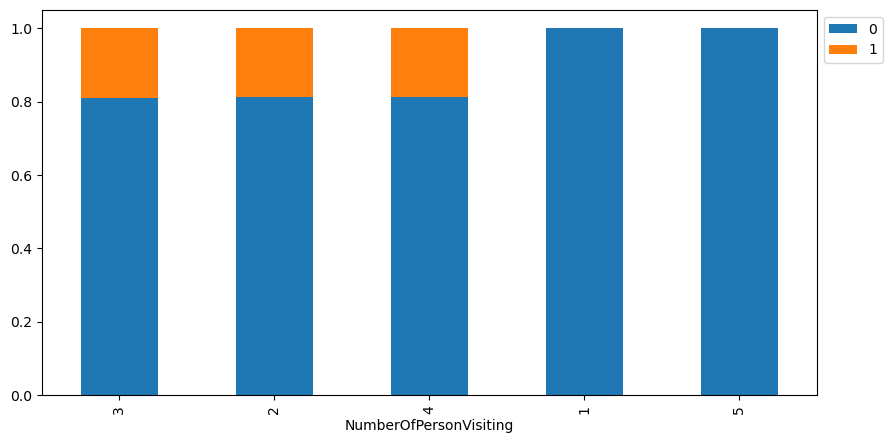

In [148]:
stacked_barplot(df, 'NumberOfPersonVisiting', 'ProdTaken')

Observation:
If they had people to go with they seem to be more likely to buy a ticket

#### NumberOfFollowups

ProdTaken             0    1   All
NumberOfFollowups                 
All                3968  920  4888
4.0                1726  387  2113
3.0                1222  244  1466
5.0                 577  191   768
6.0                  82   54   136
2.0                 205   24   229
1.0                 156   20   176
-------------------------------------------------------------------------------------------------------------------
ProdTaken                 0         1
NumberOfFollowups                    
6.0                0.602941  0.397059
5.0                0.751302  0.248698
4.0                0.816848  0.183152
3.0                0.833561  0.166439
1.0                0.886364  0.113636
2.0                0.895197  0.104803


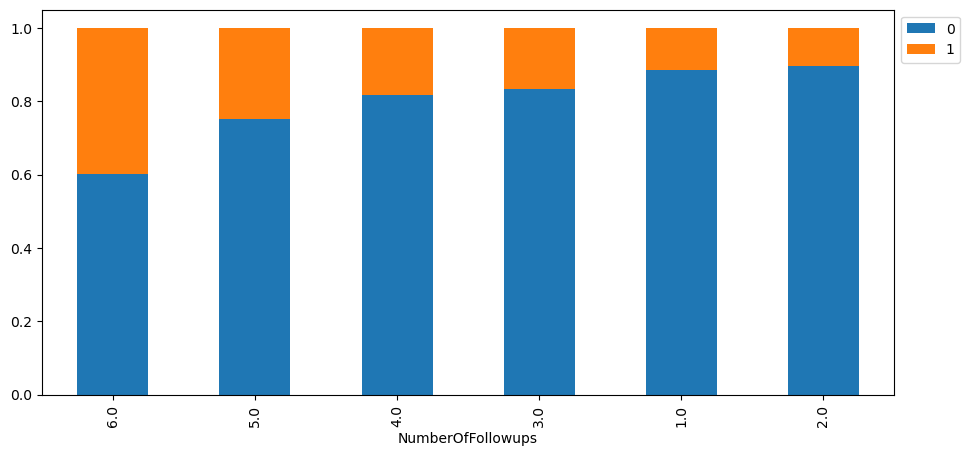

In [149]:
stacked_barplot(df, 'NumberOfFollowups', 'ProdTaken')

Observation:
The more followups the more likely they are to buy

#### PreferredPropertyStar

ProdTaken                 0    1   All
PreferredPropertyStar                 
All                    3968  920  4888
3.0                    2531  488  3019
5.0                     706  250   956
4.0                     731  182   913
-------------------------------------------------------------------------------------------------------------------
ProdTaken                     0         1
PreferredPropertyStar                    
5.0                    0.738494  0.261506
4.0                    0.800657  0.199343
3.0                    0.838357  0.161643


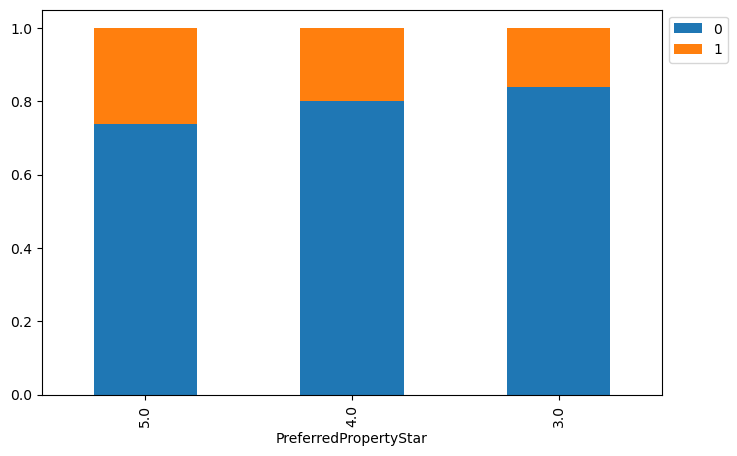

In [150]:
stacked_barplot(df, 'PreferredPropertyStar', 'ProdTaken')

Observation:
The better the hotel, the more likely to buy the product?

#### NumberOfTrips

ProdTaken         0    1   All
NumberOfTrips                 
All            3968  920  4888
2.0            1165  299  1464
3.0             990  229  1219
1.0             508  112   620
6.0             258   64   322
5.0             396   62   458
7.0             156   62   218
4.0             417   61   478
8.0              78   31   109
-------------------------------------------------------------------------------------------------------------------
ProdTaken             0         1
NumberOfTrips                    
7.0            0.715596  0.284404
8.0            0.715596  0.284404
2.0            0.795765  0.204235
6.0            0.801242  0.198758
3.0            0.812141  0.187859
1.0            0.819355  0.180645
5.0            0.864629  0.135371
4.0            0.872385  0.127615


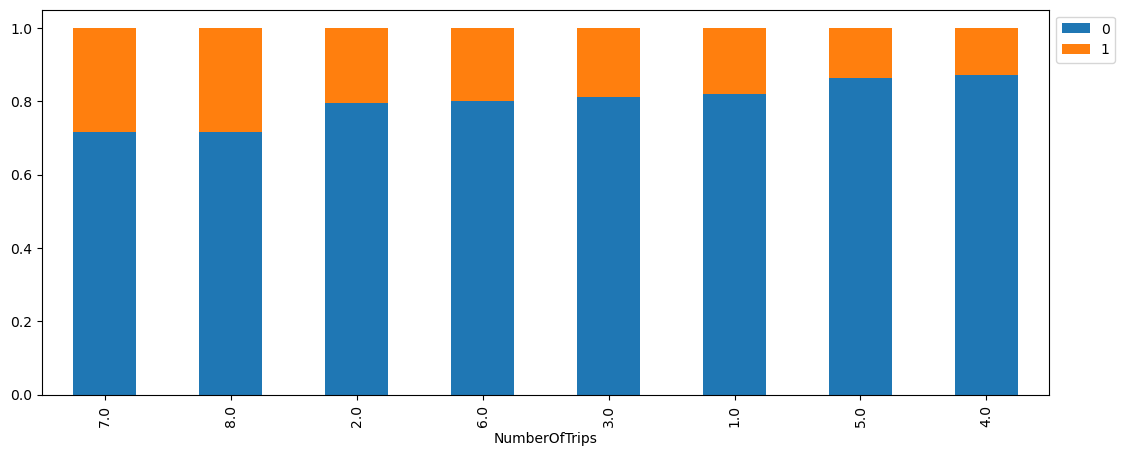

In [151]:
stacked_barplot(df, 'NumberOfTrips', 'ProdTaken')

Observation:
The people who tend to take more trips will by the product more

#### Passport

ProdTaken     0    1   All
Passport                  
All        3968  920  4888
1           928  494  1422
0          3040  426  3466
-------------------------------------------------------------------------------------------------------------------
ProdTaken         0         1
Passport                     
1          0.652602  0.347398
0          0.877092  0.122908


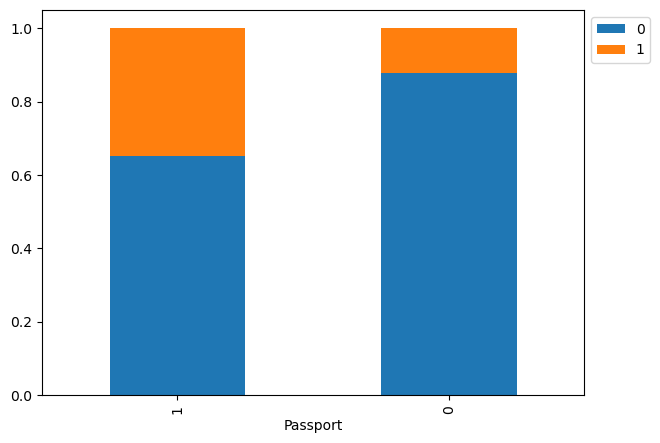

In [152]:
stacked_barplot(df, 'Passport', 'ProdTaken')

Observation:
People with a passport are way more likely to buy the product

#### PitchSatisfactionScore

ProdTaken                  0    1   All
PitchSatisfactionScore                 
All                     3968  920  4888
3                       1162  316  1478
5                        760  210   970
4                        750  162   912
1                        798  144   942
2                        498   88   586
-------------------------------------------------------------------------------------------------------------------
ProdTaken                      0         1
PitchSatisfactionScore                    
5                       0.783505  0.216495
3                       0.786198  0.213802
4                       0.822368  0.177632
1                       0.847134  0.152866
2                       0.849829  0.150171


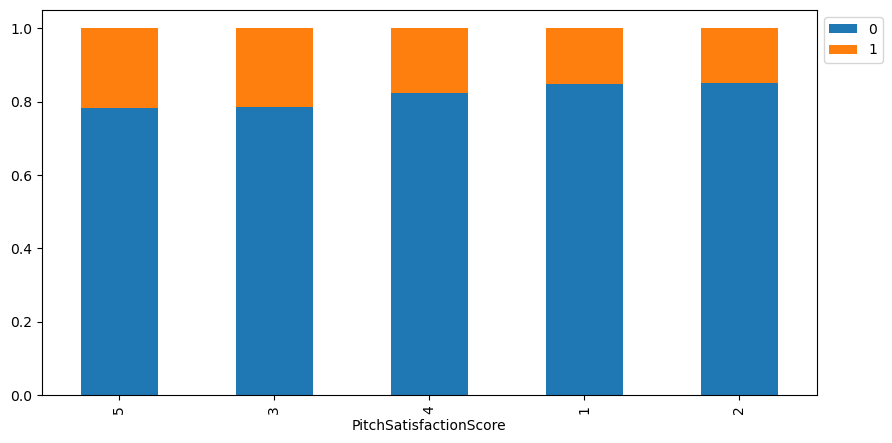

In [153]:
stacked_barplot(df, 'PitchSatisfactionScore', 'ProdTaken')

Observation:
Pitch Satisfaction Score doesn't give us much (might delete column)

#### OwnCar

ProdTaken     0    1   All
OwnCar                    
All        3968  920  4888
1          2472  560  3032
0          1496  360  1856
-------------------------------------------------------------------------------------------------------------------
ProdTaken         0         1
OwnCar                       
0          0.806034  0.193966
1          0.815303  0.184697


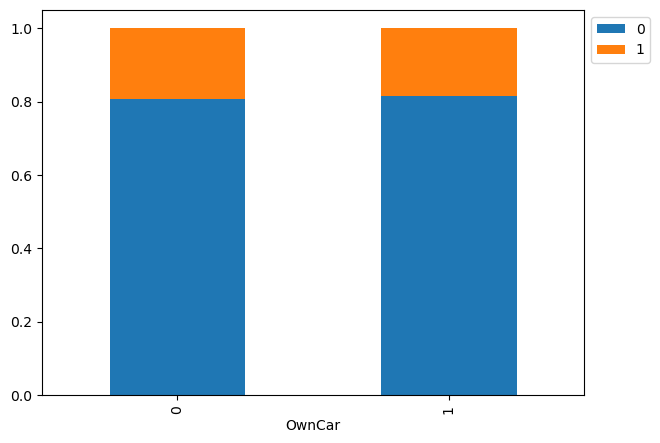

In [154]:
stacked_barplot(df, 'OwnCar', 'ProdTaken')

Observation:
No real difference seen

#### NumberOfChildrenVisiting

ProdTaken                    0    1   All
NumberOfChildrenVisiting                 
All                       3968  920  4888
1.0                       1747  399  2146
2.0                       1082  253  1335
0.0                        880  202  1082
3.0                        259   66   325
-------------------------------------------------------------------------------------------------------------------
ProdTaken                        0         1
NumberOfChildrenVisiting                    
3.0                       0.796923  0.203077
2.0                       0.810487  0.189513
0.0                       0.813309  0.186691
1.0                       0.814073  0.185927


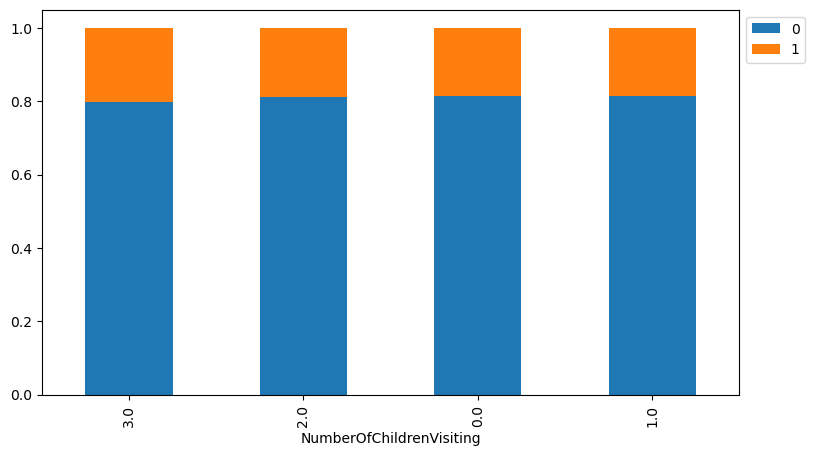

In [155]:
stacked_barplot(df, 'NumberOfChildrenVisiting', 'ProdTaken')

Observation:
Not much correlation seen

#### MonthlyIncome

<Axes: xlabel='ProdTaken', ylabel='MonthlyIncome'>

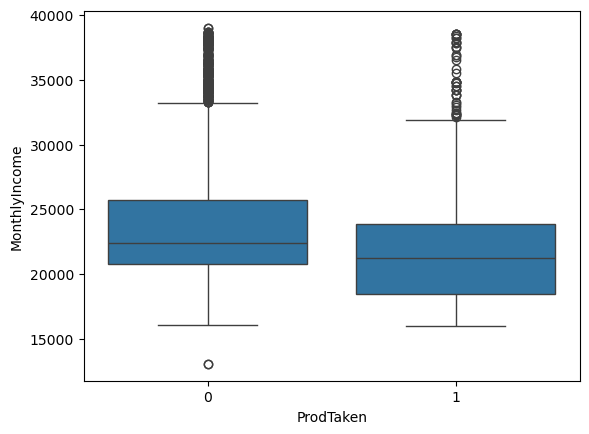

In [156]:
sns.boxplot(x='ProdTaken', y='MonthlyIncome', data=df)

Observation:
People with less monthly income by more product

## EDA Summary

- I grouped MaritalStatus together
- I found that MonthlyIncome, Passport, NumberOfTrips, NumberOfFollowups, DurationOfPitch, Age, Designation, MaritalStatus, and Occupation all seem to be the more important features for our model since there is some correlation found between each of these features and the target variable

# Feature Engineering

## Examine Categorical Feature Values

### Consolidate Values

In [157]:
df.nunique()

ProdTaken                      2
Age                           44
TypeofContact                  2
CityTier                       3
DurationOfPitch               30
Occupation                     4
Gender                         2
NumberOfPersonVisiting         5
NumberOfFollowups              6
ProductPitched                 5
PreferredPropertyStar          3
NumberOfTrips                  8
Passport                       2
PitchSatisfactionScore         5
OwnCar                         2
NumberOfChildrenVisiting       4
Designation                    5
MonthlyIncome               2473
MaritalStatus_Grouped          2
dtype: int64

Already grouped MaritalStatus and don't feel it is necessary to group any others as they don't have much cardinality

### Combine or Drop Features

The only feature I droped was the CustomerID since it was so unique

## Examine Numeric Features

### Scale

In [158]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df[['Age', 'MonthlyIncome', 'DurationOfPitch']])
df[['Age', 'MonthlyIncome', 'DurationOfPitch']] = scaler.transform(df[['Age', 'MonthlyIncome', 'DurationOfPitch']])

I only standardized Age, MonthlyIncome, and DurationOfPitch since they were the only features that had a big range while the others aren't on a large scale.

### Bin

Did not feel binning was necessary because I felt the features already showed meaningful continuous patterns

### Log

The only feature I would log would be MonthlyIncome but I prefer its standardized look

## Encode Categorical Features

In [159]:
df.sample(10)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,MaritalStatus_Grouped
1639,0,-0.609330,Self Enquiry,1,-0.414938,Salaried,Male,2,3.0,Basic,3.0,4.0,0,1,0,1.0,Executive,-1.091513,Not Married
1539,1,-0.169956,Self Enquiry,1,-0.036986,Small Business,Male,3,4.0,Basic,3.0,1.0,1,1,1,2.0,Executive,-1.022075,Married
2545,0,-0.499487,Self Enquiry,1,-1.044859,Salaried,Male,4,4.0,Basic,5.0,3.0,0,2,0,3.0,Executive,-0.378083,Not Married
2439,1,1.148165,Self Enquiry,3,-0.918875,Small Business,Male,2,4.0,Deluxe,4.0,1.0,1,1,1,0.0,Manager,-0.127311,Not Married
484,0,-0.719174,Self Enquiry,3,-0.414938,Small Business,Male,3,2.0,Deluxe,3.0,5.0,0,5,1,2.0,Manager,-0.610999,Married
4715,1,1.477696,Company Invited,3,-1.044859,Salaried,Male,3,4.0,Deluxe,3.0,5.0,1,1,1,2.0,Manager,-0.026526,Not Married
1268,0,1.697383,Company Invited,1,-1.170843,Small Business,Female,2,4.0,Super Deluxe,3.0,5.0,1,1,0,0.0,AVP,0.877959,Married
4248,0,0.928478,Self Enquiry,1,-0.036986,Salaried,Male,4,4.0,Deluxe,3.0,2.0,0,3,1,1.0,Manager,-0.231072,Married
2049,0,-0.389643,Self Enquiry,1,-0.288954,Small Business,Female,2,4.0,Basic,5.0,2.0,0,1,1,0.0,Executive,-0.236627,Not Married
20,0,-0.169956,Company Invited,1,0.214982,Salaried,Female,3,2.0,Deluxe,3.0,1.0,0,3,1,2.0,Manager,-0.236627,Married


In [160]:
df = pd.get_dummies(df, columns=['Gender','MaritalStatus_Grouped','TypeofContact','Occupation','ProductPitched', 'Designation'], drop_first=True)

In [161]:
df.sample(10)

,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,...,Occupation_Salaried,Occupation_Small Business,ProductPitched_Deluxe,ProductPitched_King,ProductPitched_Standard,ProductPitched_Super Deluxe,Designation_Executive,Designation_Manager,Designation_Senior Manager,Designation_VP
1528,0,-0.719174,1,-0.288954,2,3.0,3.0,4.0,0,3,...,True,False,True,False,False,False,False,True,False,False
1335,0,-0.169956,1,1.222855,2,3.0,3.0,1.0,0,5,...,True,False,True,False,False,False,False,True,False,False
4129,0,0.489105,3,-0.288954,4,4.0,3.0,5.0,1,1,...,True,False,False,False,True,False,False,False,True,False
2057,0,1.587539,1,0.214982,2,3.0,3.0,1.0,0,1,...,True,False,True,False,False,False,False,True,False,False
2823,0,2.026913,1,-0.792891,4,4.0,3.0,4.0,1,5,...,True,False,False,False,False,True,False,False,False,False
2920,0,-1.378234,1,1.096871,4,5.0,4.0,3.0,0,3,...,True,False,False,False,False,False,True,False,False,False
3224,1,-0.938861,1,1.978760,4,5.0,5.0,3.0,0,2,...,False,False,False,False,True,False,False,False,True,False
402,0,-0.829017,3,0.340966,2,3.0,3.0,1.0,0,2,...,False,False,True,False,False,False,False,True,False,False
1594,1,-0.719174,3,-0.414938,3,5.0,3.0,5.0,1,3,...,True,False,True,False,False,False,False,True,False,False
3381,0,0.269418,1,0.592935,4,5.0,4.0,3.0,1,3,...,False,True,False,False,False,True,False,False,False,False


## Review data

### Define independent and dependant variables

In [162]:
X = df.drop(["ProdTaken"], axis=1)
Y = df["ProdTaken"]

In [163]:
X.shape

(4888, 26)

In [164]:
Y.shape

(4888,)

In [165]:
X = pd.get_dummies(X, columns=X.select_dtypes(include=["object"]).columns.tolist(), drop_first=True)

In [166]:
X.shape

(4888, 26)

### Create the test and training sets

In [167]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [168]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3421, 26)
(1467, 26)
(3421,)
(1467,)


### Fit linear model

In [169]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [170]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred_train = log_model.predict(x_train)
y_pred_test = log_model.predict(x_test)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test))

print("\nROC AUC:", roc_auc_score(y_test, log_model.predict_proba(x_test)[:,1]))

Train Accuracy: 0.847413037123648
Test Accuracy: 0.8214042263122018

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.83      0.98      0.90      1171
           1       0.68      0.21      0.32       296

    accuracy                           0.82      1467
   macro avg       0.76      0.59      0.61      1467
weighted avg       0.80      0.82      0.78      1467


Confusion Matrix (Test):
[[1142   29]
 [ 233   63]]

ROC AUC: 0.7947642347727746


In [171]:
for idx, col_name in enumerate(x_train.columns):
    print("The coefficient for {} is {}".format(col_name, log_model.coef_[0][idx]))

The coefficient for Age is -0.15302212282516983
The coefficient for CityTier is 0.5047605471904364
The coefficient for DurationOfPitch is 0.29346550122250403
The coefficient for NumberOfPersonVisiting is -0.17971078862567538
The coefficient for NumberOfFollowups is 0.39038619942797725
The coefficient for PreferredPropertyStar is 0.393589836829919
The coefficient for NumberOfTrips is 0.03392934238404365
The coefficient for Passport is 1.6184254021726725
The coefficient for PitchSatisfactionScore is 0.12414459516186613
The coefficient for OwnCar is 0.010975992841794242
The coefficient for NumberOfChildrenVisiting is -0.0809193232674552
The coefficient for MonthlyIncome is 0.1317224833897832
The coefficient for Gender_Male is 0.24891751544237478
The coefficient for MaritalStatus_Grouped_Not Married is 0.5675818054962773
The coefficient for TypeofContact_Self Enquiry is -0.3251033905531195
The coefficient for Occupation_Large Business is 0.01569371575419425
The coefficient for Occupation_S

Since the dependent variable (ProdTaken) is binary, logistic regression was used instead of linear regression to appropriately model classification outcomes.

## Summary

Data preprocessing and feature engineering steps were conducted to prepare the dataset for machine learning modeling. Missing values were handled using appropriate statistical methods such as median and mode imputation. Outliers were evaluated using boxplots and IQR analysis, with extreme values capped where necessary while preserving meaningful behavioral observations.

Categorical features were examined for inconsistencies and consolidated when appropriate, such as grouping marital status categories. Numeric features were analyzed for skewness and scaled using standardization to normalize magnitude differences. Binning and log transformations were evaluated but not applied, as the variables retained meaningful continuous relationships after preprocessing.

Categorical variables were encoded using one-hot encoding to ensure compatibility with machine learning algorithms. Finally, independent and dependent variables were defined, and the dataset was split into training and testing sets to support model development and evaluation.

### Notes after reviewing with partner

After reviewing our work during class with Jack, we realized that we approached the assignment very similarly. The main difference was that he grouped more features together to simplify the dataset. His training and testing accuracy ended up slightly lower than mine, and I wasn’t able to find a way to improve my model’s accuracy further.

Because of that, I decided to leave my notebook as it is. However, it was really helpful to compare notebooks and see how someone else organized and prepared their data. It was interesting to notice the differences in how we structured and engineered our features.

If possible, I would appreciate any feedback or comments on how I could improve my notebook to achieve better accuracy.